# Índice de Vulnerabilidad Financiera — Personas No Bancarizadas del Perú
## ENAHO 2024 | Pipeline actualizado

**Decisión geográfica:** `area`, `dominio_macro` y `tamano_poblacional` no entran directamente al score Vi ni a `X_gmm`/GMM. Se usan para caracterización territorial, heterogeneidad posterior y comparación auxiliar en XGBoost. Como precisión metodológica, `dominio` y `estrato` sí se usan solo como predictores auxiliares en la imputación MICE del ingreso.

**Módulos usados:** 100, 200, 300, 500

In [ ]:
# ============================================================
# BLOQUE 0 — Instalación de librerías (ejecutar solo una vez)
# ============================================================
!pip install prince miceforest xgboost shap --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 2.3 MB/s eta 0:00:00


In [ ]:
# ============================================================
# BLOQUE 1 — Imports y configuración global
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

# Ruta base donde están los CSV de ENAHO
from google.colab import drive
drive.mount('/content/drive')
BASE_PATH = "/content/drive/MyDrive/Inv. Est."
# BASE_PATH = "/content"   # <-- ajusta si es necesario

MICE_THRESHOLD = 0.05   # umbral para MICE (Van Buuren, 2018)

print("✔ Librerías cargadas")
print(f"  Ruta base      : {BASE_PATH}")
print(f"  Umbral MICE    : {MICE_THRESHOLD*100:.0f}%")
print(f"  Semilla global : {SEED}")

Mounted at /content/drive
✔ Librerías cargadas
  Ruta base      : /content/drive/MyDrive/Inv. Est.
  Umbral MICE    : 5%
  Semilla global : 42


In [ ]:
# ============================================================
# BLOQUE 2 — Carga de módulos ENAHO
# ============================================================
VARS_M100 = [
    "CONGLOME", "VIVIENDA", "HOGAR",
    "UBIGEO", "DOMINIO", "ESTRATO",
    "P101", "P102", "P103", "P110", "P111A", "P1121",
    "NBI1", "NBI2", "NBI3", "NBI4", "NBI5",
    "P1142", "P1144", "P1144B1", "P1144B2", "P1144B3", "P1145",
    "P107B1", "P107B2", "P107B3", "P107B4", "P107E",
]

VARS_M200 = [
    "CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO",
    "P203",
    "P207",
    "P208A",
    "P209",
]

VARS_M300 = [
    "CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO",
    "P301A",
    "P302",
]

VARS_M500 = [
    "CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO",
    # Empleo
    "P507",
    "P511A",
    "P512A",
    "P524A1",  # ingreso trabajo DEPENDIENTE (asalariado)
    "P530A",   # ← NUEVO: ganancia neta trabajo INDEPENDIENTE (negocio propio)
               #   Fuente: Diccionario ENAHO 2024, pág. 223
               #   "En la ocupación principal ¿Cuál fue la ganancia neta en el mes anterior?"
               #   Centinela: 999999
    # Inclusión financiera
    "P558A5",
    "P558C",
    "P558E1_1", "P558E1_2", "P558E1_3", "P558E1_4",
    "P558E1_6", "P558E1_7", "P558E1_8", "P558E1_9", "P558E1_10",
    "P558F1A",
    "P558F1B",
    "P558G1", "P558G2", "P558G3", "P558G5",
    "P558G6", "P558G7", "P558G8",
    "FAC500A",
]

ID_HOGAR   = ["CONGLOME", "VIVIENDA", "HOGAR"]
ID_PERSONA = ["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO"]

def leer_csv(nombre, vars_usar):
    path = os.path.join(BASE_PATH, nombre)
    for enc in ["utf-8", "latin-1"]:
        try:
            df = pd.read_csv(
                path,
                usecols=lambda c: c in vars_usar,
                encoding=enc,
                low_memory=False,
            )
            id_cols = [c for c in ID_PERSONA if c in df.columns]
            df[id_cols] = df[id_cols].astype(str).apply(lambda s: s.str.strip())
            faltantes = [v for v in vars_usar if v not in df.columns]
            if faltantes:
                print(f"  ⚠ {nombre}: variables NO encontradas → {faltantes}")
            print(f"  ✔ {nombre}: {len(df):,} filas — encoding: {enc}")
            return df
        except Exception as e:
            err = e
    raise RuntimeError(f"Error leyendo {nombre}: {err}")

m100 = leer_csv("Enaho01-2024-100.csv",  VARS_M100)
m200 = leer_csv("Enaho01-2024-200.csv",  VARS_M200)
m300 = leer_csv("Enaho01A-2024-300.csv", VARS_M300)
m500 = leer_csv("Enaho01a-2024-500.csv", VARS_M500)

print("\n✔ Módulos cargados")


  ⚠ Enaho01-2024-100.csv: variables NO encontradas → ['P1144B1', 'P1144B2', 'P1144B3']
  ✔ Enaho01-2024-100.csv: 44,731 filas — encoding: latin-1
  ✔ Enaho01-2024-200.csv: 117,721 filas — encoding: latin-1
  ✔ Enaho01A-2024-300.csv: 106,619 filas — encoding: latin-1
  ✔ Enaho01a-2024-500.csv: 85,992 filas — encoding: latin-1

✔ Módulos cargados


In [ ]:
# ============================================================
# BLOQUE 3 — Integración de módulos a nivel persona
# ============================================================
df = m500.copy()
df = df.merge(m200, on=ID_PERSONA, how="left")
df = df.merge(m300, on=ID_PERSONA, how="left")
df = df.merge(m100, on=ID_HOGAR,   how="left")

n_panel = len(df)
n_sin_m200 = df["P207"].isna().sum()

print(f"M500 (base)          : {len(m500):,} personas")
print(f"Panel tras merges    : {n_panel:,} personas × {df.shape[1]} variables")
print(f"Sin match en M200    : {n_sin_m200:,} ({n_sin_m200/n_panel:.1%})")
print(f"\nColumnas disponibles ({df.shape[1]}):\n{list(df.columns)}")



M500 (base)          : 85,992 personas
Panel tras merges    : 85,992 personas × 58 variables
Sin match en M200    : 0 (0.0%)

Columnas disponibles (58):
['CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO', 'P507', 'P511A', 'P512A', 'P524A1', 'P530A', 'P558A5', 'P558C', 'P558E1_1', 'P558E1_2', 'P558E1_3', 'P558E1_4', 'P558E1_6', 'P558E1_7', 'P558E1_8', 'P558E1_9', 'P558E1_10', 'P558F1A', 'P558F1B', 'P558G1', 'P558G2', 'P558G3', 'P558G5', 'P558G6', 'P558G7', 'P558G8', 'FAC500A', 'P203', 'P207', 'P208A', 'P209', 'P301A', 'P302', 'DOMINIO', 'UBIGEO', 'ESTRATO', 'P101', 'P102', 'P103', 'P107B1', 'P107B2', 'P107B3', 'P107B4', 'P107E', 'P110', 'P111A', 'P1121', 'P1142', 'P1144', 'P1145', 'NBI1', 'NBI2', 'NBI3', 'NBI4', 'NBI5']


In [ ]:
# ============================================================
# BLOQUE 4 — Filtro: población objetivo 18–65 años no bancarizada
# ============================================================
df["P558E1_6"] = pd.to_numeric(df["P558E1_6"], errors="coerce")
df["P208A"]    = pd.to_numeric(df["P208A"],    errors="coerce")

n_total = len(df)
df_nb = df[
    (df["P558E1_6"] == 6) &
    (df["P208A"].between(18, 65))
].copy()

print(f"Población total en panel        : {n_total:,}")
print(f"No bancarizados (18-65 años)    : {len(df_nb):,}")
print(f"Proporción sobre el panel total : {len(df_nb)/n_total:.1%}")



Población total en panel        : 85,992
No bancarizados (18-65 años)    : 29,954
Proporción sobre el panel total : 34.8%


In [ ]:
# ============================================================
# BLOQUE 5 — Limpieza de centinelas y selección de variables
# ============================================================
VARS_ANALISIS = {
    "P207"   : "sexo",
    "P208A"  : "edad",
    "P209"   : "estado_civil",
    "DOMINIO" : "dominio",
    "ESTRATO" : "estrato",
    "UBIGEO"  : "ubigeo",
    "P301A"  : "nivel_educativo",
    "P302"   : "alfabetismo",
    "P507"   : "categoria_ocupacional",
    "P511A"  : "tipo_contrato",
    "P512A"  : "tamano_empresa",
    "P524A1" : "ingreso_dep",    # ← renombrado: ingreso dependiente
    "P530A"  : "ingreso_ind",    # ← NUEVO: ingreso independiente
    "P558A5" : "sin_pension",
    "P558C"  : "etnia",
    "NBI1"   : "nbi_vivienda_inadecuada",
    "NBI2"   : "nbi_hacinamiento",
    "NBI3"   : "nbi_sin_sshh",
    "NBI4"   : "nbi_ninos_sin_escuela",
    "NBI5"   : "nbi_alta_dependencia",
    "P558F1A": "razon_sin_cuenta",
    "P558F1B": "razon_sin_credito",
    "P558G1" : "ahorro_junta",
    "P558G2" : "ahorro_conocidos",
    "P558G3" : "ahorro_casa",
    "P558G5" : "no_ahorro_ni_presto",
    "P558G6" : "presto_dinero",
    "P558G7" : "recibio_prestamo_informal",
    "P558G8" : "ahorro_banco",
    "P1142"   : "tiene_computadora",
    "P1144"   : "tiene_internet",
    "P1144B1" : "internet_banda_ancha",
    "P1144B2" : "internet_cable",
    "P1144B3" : "internet_movil",
    "P1145"   : "usa_internet_personal",
    "P107B1"  : "dificultad_pago_cuota",
    "P107B2"  : "atraso_pago",
    "P107B3"  : "renegocio_deuda",
    "P107B4"  : "perdio_garantia",
    "P107E"   : "deuda_pendiente_vivienda",
    "FAC500A" : "factor_expansion",
}

cols_ok = {k: v for k, v in VARS_ANALISIS.items() if k in df_nb.columns}
cols_faltantes = [k for k in VARS_ANALISIS if k not in df_nb.columns]

# Guardar códigos originales antes de renombrar
P507_raw  = pd.to_numeric(df_nb["P507"],  errors="coerce").values
P511A_raw = pd.to_numeric(df_nb["P511A"], errors="coerce").values

df_sel = df_nb[list(cols_ok.keys())].rename(columns=cols_ok).copy()

if cols_faltantes:
    print(f"⚠ Variables NO encontradas en el panel: {cols_faltantes}")
print(f"\nVariables seleccionadas : {len(cols_ok)}")
print(f"Shape: {df_sel.shape}")

# Centinelas → NaN
CENTINELAS = {
    "estado_civil"            : [9],
    "nivel_educativo"         : [9],
    "alfabetismo"             : [9],
    "categoria_ocupacional"   : [9],
    "tipo_contrato"           : [9],
    "tamano_empresa"          : [9],
    "sin_pension"             : [9],
    "etnia"                   : [9],
    "razon_sin_cuenta"        : [99, 9],
    "razon_sin_credito"       : [99, 9],
    "dominio"                 : [9],
    "estrato"                 : [9],
    "tiene_computadora"       : [9],
    "tiene_internet"          : [9],
    "internet_banda_ancha"    : [9],
    "internet_cable"          : [9],
    "internet_movil"          : [9],
    "usa_internet_personal"   : [9],
    "dificultad_pago_cuota"   : [9],
    "atraso_pago"             : [9],
    "renegocio_deuda"         : [9],
    "perdio_garantia"         : [9],
    "deuda_pendiente_vivienda": [9],
    # ← NUEVO: centinelas de variables de ingreso
    "ingreso_dep"             : [999999],  # P524A1: 999999 = no declara
    "ingreso_ind"             : [999999],  # P530A:  999999 = no declara
}

print("\nConvirtiendo centinelas a NaN...")
for var, codigos in CENTINELAS.items():
    if var not in df_sel.columns:
        continue
    col = pd.to_numeric(df_sel[var], errors="coerce")
    n_antes = col.isna().sum()
    col = col.replace(codigos, np.nan)
    n_despues = col.isna().sum()
    df_sel[var] = col
    if n_despues > n_antes:
        print(f"  [{var}] {n_despues - n_antes:,} centinelas → NaN")

print("\n✔ Centinelas procesados")




⚠ Variables NO encontradas en el panel: ['P1144B1', 'P1144B2', 'P1144B3']

Variables seleccionadas : 38
Shape: (29954, 38)

Convirtiendo centinelas a NaN...
  [nivel_educativo] 1,371 centinelas → NaN
  [alfabetismo] 13 centinelas → NaN
  [etnia] 53 centinelas → NaN
  [razon_sin_credito] 583 centinelas → NaN
  [ingreso_dep] 71 centinelas → NaN
  [ingreso_ind] 1,804 centinelas → NaN

✔ Centinelas procesados


Reporte de valores faltantes:

                 variable  pct_missing  n_missing metodo_imputacion
           tamano_empresa       0.2162       6476              MICE
    categoria_ocupacional       0.2161       6472              MICE
          nivel_educativo       0.0458       1371 imputacion_simple
        razon_sin_credito       0.0211        633 imputacion_simple
                    etnia       0.0018         53 imputacion_simple
                     edad       0.0000          0      sin_missings
             estado_civil       0.0000          0      sin_missings
              sin_pension       0.0000          0      sin_missings
  nbi_vivienda_inadecuada       0.0000          0      sin_missings
         nbi_hacinamiento       0.0000          0      sin_missings
             nbi_sin_sshh       0.0000          0      sin_missings
    nbi_ninos_sin_escuela       0.0000          0      sin_missings
                     sexo       0.0000          0      sin_missings
     nbi_alta_dep

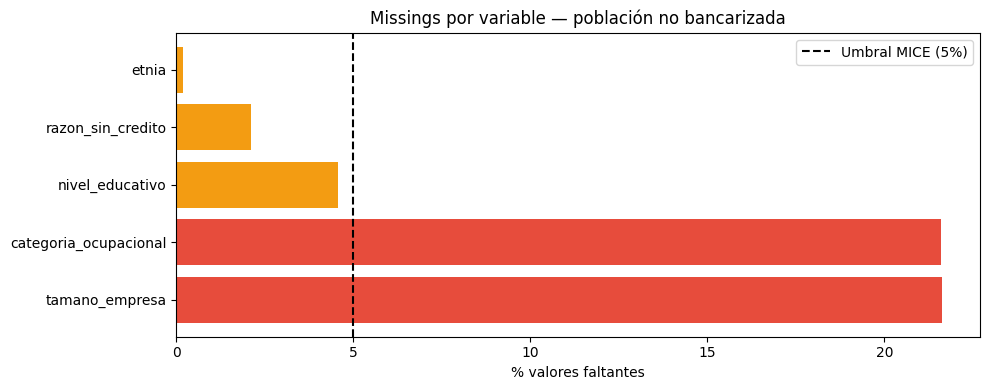


Imputación simple (mediana/moda):
  [nivel_educativo] → mediana = 5.0
  [razon_sin_credito] → mediana = 6.0
  [etnia] → mediana = 6.0

MICE aplicado a: ['tamano_empresa', 'categoria_ocupacional']
  MICE completado ✔

Missings restantes (excl. ingreso): 0


In [ ]:
# ============================================================
# BLOQUE 6 — Diagnóstico de valores faltantes e imputación
# ============================================================
import miceforest as mf

# Variables excluidas del análisis de missings/MICE:
#   ingreso_dep, ingreso_ind : lógica propia en Bloque 9
#   alfabetismo              : 78.3% missing — cobertura incompleta de M300
#                              solo se usará para caracterización donde exista
#   tipo_contrato            : 63.4% missing — solo se usa para construir
#                              "informalidad" (P511A_raw), no entra a VARS_MCA
#   deuda_pendiente_vivienda : 97.5% missing — excluida de dificultad_pago_credito
#                              (ver Bloque 8 actualizado)
EXCLUIR_DE_MICE = [
    "ingreso_dep", "ingreso_ind",
    "factor_expansion", "ubigeo", "dominio", "estrato",
    "alfabetismo",              # 78.3% missing
    "tipo_contrato",            # 63.4% missing
    "deuda_pendiente_vivienda", # 97.5% missing
]
cols_para_mice = [c for c in df_sel.columns if c not in EXCLUIR_DE_MICE]

miss_pct = df_sel[cols_para_mice].isnull().mean().sort_values(ascending=False)

miss_df = pd.DataFrame({
    "variable"          : miss_pct.index,
    "pct_missing"       : miss_pct.values.round(4),
    "n_missing"         : df_sel[cols_para_mice].isnull().sum()[miss_pct.index].values,
    "metodo_imputacion" : np.where(
        miss_pct.values == 0,                        "sin_missings",
        np.where(miss_pct.values <= MICE_THRESHOLD,  "imputacion_simple", "MICE")
    )
})

print("Reporte de valores faltantes:\n")
print(miss_df.to_string(index=False))

# Gráfico
vars_con_miss = miss_df[miss_df["pct_missing"] > 0].copy()
if len(vars_con_miss) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(vars_con_miss) * 0.4)))
    colores = ["#e74c3c" if p > MICE_THRESHOLD else "#f39c12"
               for p in vars_con_miss["pct_missing"]]
    ax.barh(vars_con_miss["variable"], vars_con_miss["pct_missing"] * 100, color=colores)
    ax.axvline(MICE_THRESHOLD * 100, color="black", linestyle="--",
               label=f"Umbral MICE ({MICE_THRESHOLD*100:.0f}%)")
    ax.set_xlabel("% valores faltantes")
    ax.set_title("Missings por variable — población no bancarizada")
    ax.legend(); plt.tight_layout()
    plt.savefig("missings.png", dpi=150); plt.show()

# Imputación
df_imp = df_sel.copy()

vars_simple = miss_df.loc[
    (miss_df["pct_missing"] > 0) &
    (miss_df["pct_missing"] <= MICE_THRESHOLD), "variable"
].tolist()

vars_mice = miss_df.loc[
    miss_df["pct_missing"] > MICE_THRESHOLD, "variable"
].tolist()

print("\nImputación simple (mediana/moda):")
for var in vars_simple:
    if var not in df_imp.columns:
        continue
    if pd.api.types.is_numeric_dtype(df_imp[var]):
        val    = df_imp[var].median()
        metodo = "mediana"
    else:
        val    = df_imp[var].mode()[0]
        metodo = "moda"
    df_imp[var] = df_imp[var].fillna(val)
    print(f"  [{var}] → {metodo} = {val}")

if vars_mice:
    print(f"\nMICE aplicado a: {vars_mice}")
    df_mice_in = df_imp[vars_mice].copy()
    for col in df_mice_in.select_dtypes(include="object").columns:
        df_mice_in[col] = pd.Categorical(df_mice_in[col]).codes.astype(float)
        df_mice_in[col] = df_mice_in[col].replace(-1, np.nan)
    df_mice_in = df_mice_in.reset_index(drop=True)
    kernel = mf.ImputationKernel(data=df_mice_in, num_datasets=5, random_state=SEED)
    kernel.mice(3)
    df_imp[vars_mice] = kernel.complete_data(dataset=0).values
    print("  MICE completado ✔")
else:
    print("\nNo hay variables que requieran MICE ✔")

print(f"\nMissings restantes (excl. ingreso): {df_imp[cols_para_mice].isnull().sum().sum()}")



In [ ]:
# ============================================================
# BLOQUE 7 — Recodificación geográfica
# ============================================================
df_rec = df_imp.copy()
df_rec["P507_raw"]  = P507_raw
df_rec["P511A_raw"] = P511A_raw

estrato_num = pd.to_numeric(df_rec["estrato"], errors="coerce")
dominio_num = pd.to_numeric(df_rec["dominio"], errors="coerce")

df_rec["area"] = None
df_rec.loc[estrato_num.isin([7, 8]), "area"] = "Rural"
df_rec.loc[estrato_num.between(1, 6), "area"] = "Urbano"

df_rec["tamano_poblacional"] = estrato_num.map({
    1: "Ciudad grande", 2: "Ciudad grande",
    3: "Ciudad mediana", 4: "Ciudad mediana",
    5: "CP pequeño",    6: "CP pequeño",
    7: "Rural",         8: "Rural",
})

df_rec["dominio_macro"] = dominio_num.map({
    1: "Costa",  2: "Costa",  3: "Costa",
    4: "Sierra", 5: "Sierra", 6: "Sierra",
    7: "Selva",
    8: "Lima Metropolitana",
})

nulos_area    = df_rec["area"].isna().sum()
nulos_dominio = df_rec["dominio_macro"].isna().sum()
if nulos_area    > 0: print(f"⚠ area: {nulos_area} NaN")
if nulos_dominio > 0: print(f"⚠ dominio_macro: {nulos_dominio} NaN")

print("Recodificación territorial ✔")
print(f"\nDistribución area:\n{df_rec['area'].value_counts()}")
print(f"\nDistribución dominio_macro:\n{df_rec['dominio_macro'].value_counts()}")



Recodificación territorial ✔

Distribución area:
area
Urbano    19204
Rural     10750
Name: count, dtype: int64

Distribución dominio_macro:
dominio_macro
Sierra                11042
Costa                  9081
Selva                  7346
Lima Metropolitana     2485
Name: count, dtype: int64


In [ ]:
# ============================================================
# BLOQUE 8 — Construcción de acceso_digital y dificultad_pago_credito
# ============================================================
def binaria(col, val_si=1):
    s = pd.to_numeric(col, errors="coerce")
    return (s == val_si).astype(float)

comp_digital = pd.DataFrame(index=df_rec.index)
comp_digital["d_computadora"] = binaria(df_rec.get("tiene_computadora",
                                pd.Series(np.nan, index=df_rec.index)))
comp_digital["d_internet"]    = binaria(df_rec.get("tiene_internet",
                                pd.Series(np.nan, index=df_rec.index)))
comp_digital["d_conexion_avanzada"] = np.where(
    (binaria(df_rec.get("internet_banda_ancha", pd.Series(np.nan, index=df_rec.index))) == 1) |
    (binaria(df_rec.get("internet_cable",       pd.Series(np.nan, index=df_rec.index))) == 1),
    1.0, 0.0
)
comp_digital["d_uso_personal"] = binaria(df_rec.get("usa_internet_personal",
                                  pd.Series(np.nan, index=df_rec.index)))

df_rec["acceso_digital"] = comp_digital.sum(axis=1)

# deuda_pendiente_vivienda EXCLUIDA (97.5% missing — ver Bloque 6)
# Score construido con 4 componentes restantes (rango conceptual 0–4).
# En esta ejecución resultó sin variabilidad efectiva (=4), por eso no se
# incorpora al score Vi ni a X_gmm; queda disponible solo como diagnóstico.
cols_credito = ["dificultad_pago_cuota", "atraso_pago",
                "renegocio_deuda", "perdio_garantia"]
cols_credito_pres = [c for c in cols_credito if c in df_rec.columns]

if cols_credito_pres:
    df_rec["dificultad_pago_credito"] = (
        df_rec[cols_credito_pres]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0).clip(upper=1).sum(axis=1)
    )
else:
    df_rec["dificultad_pago_credito"] = 0
    print("⚠ Variables de crédito vivienda no encontradas.")

print("✔ Variables compuestas construidas")
print(f"\nacceso_digital (0–4):\n{df_rec['acceso_digital'].value_counts().sort_index()}")
print(f"\ndificultad_pago_credito (0–4):\n{df_rec['dificultad_pago_credito'].value_counts().sort_index()}")



✔ Variables compuestas construidas

acceso_digital (0–4):
acceso_digital
0.0       66
1.0     2152
2.0    27736
Name: count, dtype: int64

dificultad_pago_credito (0–4):
dificultad_pago_credito
4    29954
Name: count, dtype: int64


In [ ]:
# ============================================================
# BLOQUE 9 — Recodificación socioeconómica base
# ============================================================

# — Sexo —
df_rec["sexo"] = pd.to_numeric(df_rec["sexo"], errors="coerce").map(
    {1: "Hombre", 2: "Mujer", 1.0: "Hombre", 2.0: "Mujer"}
)
print(f"Sexo:\n{df_rec['sexo'].value_counts(dropna=False)}")

# — Estado civil —
df_rec["estado_civil"] = pd.to_numeric(df_rec["estado_civil"], errors="coerce").map({
    1: "Conviviente", 2: "Casado/a",   3: "Viudo/a",
    4: "Divorciado/a", 5: "Separado/a", 6: "Soltero/a"
})

# — Nivel educativo ordinal —
edu_map = {
    1: 0,  2: 1,  3: 2,  4: 3,  5: 4,  6: 5,
    7: 6,  8: 7,  9: 8, 10: 9, 11: 10, 12: 0,
}
df_rec["nivel_educativo_ord"] = df_rec["nivel_educativo"].map(edu_map)

# — Nivel educativo categórico para MCA —
edu_cat_map = {
    0: "Sin_nivel",       1: "Inicial",
    2: "Primaria_inc",    3: "Primaria_comp",
    4: "Secundaria_inc",  5: "Secundaria_comp",
    6: "Sup_no_univ_inc", 7: "Sup_no_univ_comp",
    8: "Sup_univ_inc",    9: "Sup_univ_comp",
    10: "Maestria_doc",
}
df_rec["nivel_educativo_cat"] = df_rec["nivel_educativo_ord"].map(edu_cat_map)

# — Categoría ocupacional —
ocup_map = {
    1: "Empleador", 2: "Independiente", 3: "Empleado",
    4: "Obrero",    5: "TFNR",          6: "Trab_hogar", 7: "Otro"
}
df_rec["categoria_ocupacional"] = df_rec["P507_raw"].map(ocup_map)

# — Informalidad y empleo vulnerable —
df_rec["informalidad"] = np.where(
    df_rec["P507_raw"].isin([2, 5, 6]) | (df_rec["P511A_raw"] == 7), 1, 0
)
df_rec["empleo_vulnerable"] = np.where(
    df_rec["P507_raw"].isin([2, 5]), 1, 0
)

# — NBI score —
nbi_cols = [c for c in ["nbi_vivienda_inadecuada", "nbi_hacinamiento", "nbi_sin_sshh",
                         "nbi_ninos_sin_escuela",   "nbi_alta_dependencia"]
            if c in df_rec.columns]
for nbi in nbi_cols:
    df_rec[nbi] = pd.to_numeric(df_rec[nbi], errors="coerce").fillna(0).astype(int)
df_rec["nbi_score"] = df_rec[nbi_cols].sum(axis=1)

# ============================================================
# — INGRESO TOTAL MENSUAL (lógica corregida + imputación MICE) —
# ============================================================
# Fuentes verificadas en Diccionario ENAHO 2024:
#   ingreso_dep (P524A1): ingreso dependiente — aplica a P507 = 3, 4, 6
#   ingreso_ind (P530A) : ganancia neta independiente — aplica a P507 = 1, 2
#   TFNRs (P507=5)      : ingreso = 0 genuino (trabajo no remunerado)
#
# Centinelas ya fueron convertidos a NaN en el Bloque 5.
# El ~28% de NaN restante (sin ingreso reportado en dep. ni indep.)
# se imputa con MICE en vez de mediana global, usando como predictores
# variables correlacionadas con el ingreso (educación, ocupación, zona,
# tamaño de empresa, NBI). Se trabaja en log para evitar imputaciones
# fuera de rango, dado que el ingreso suele tener distribución asimétrica.

p507_raw_s = pd.Series(P507_raw, index=df_rec.index)

es_dependiente   = p507_raw_s.isin([3, 4, 6])
es_independiente = p507_raw_s.isin([1, 2])
es_tfnr          = p507_raw_s.isin([5])

ing_dep = pd.to_numeric(df_rec["ingreso_dep"], errors="coerce")
ing_ind = pd.to_numeric(df_rec["ingreso_ind"], errors="coerce")

# Eliminar valores <= 0 (además del centinela ya limpiado)
ing_dep = ing_dep.where(ing_dep > 0, np.nan)
ing_ind = ing_ind.where(ing_ind > 0, np.nan)

# Construir ingreso_total por grupo
ingreso_total = pd.Series(np.nan, index=df_rec.index)
ingreso_total[es_dependiente]   = ing_dep[es_dependiente]
ingreso_total[es_independiente] = ing_ind[es_independiente]
ingreso_total[es_tfnr]          = 0.0   # sin remuneración monetaria

# Diagnóstico antes de imputar
n_con_ing   = (ingreso_total > 0).sum()
n_cero_tfnr = (ingreso_total == 0).sum()
n_nan       = ingreso_total.isna().sum()

print(f"\nIngreso total — antes de imputar:")
print(f"  Con ingreso real (>0)  : {n_con_ing:,} ({n_con_ing/len(ingreso_total):.1%})")
print(f"  Cero genuino (TFNRs)   : {n_cero_tfnr:,} ({n_cero_tfnr/len(ingreso_total):.1%})")
print(f"  NaN a imputar          : {n_nan:,} ({n_nan/len(ingreso_total):.1%})")

# Distribución de quienes sí tienen ingreso real (solo para referencia/diagnóstico)
ing_real = ingreso_total[ingreso_total > 0]
print(f"\n  Distribución ingreso real (referencia):")
print(f"    Mediana : S/ {ing_real.median():.0f}")
print(f"    Media   : S/ {ing_real.mean():.0f}")
print(f"    p25     : S/ {ing_real.quantile(.25):.0f}")
print(f"    p75     : S/ {ing_real.quantile(.75):.0f}")
print(f"    p90     : S/ {ing_real.quantile(.90):.0f}")
print(f"    p99     : S/ {ing_real.quantile(.99):.0f}")

# ------------------------------------------------------------
# Imputación MICE del ingreso (en vez de mediana global)
# ------------------------------------------------------------
# Predictores: variables ya construidas/recodificadas en este mismo
# bloque y bloques previos, correlacionadas con nivel de ingreso.
# Los TFNR (ingreso = 0 genuino) no reemplazan su ingreso final:
# se marcan como missing en la variable objetivo log_ingreso para que MICE
# no aprenda un cero artificial como ingreso monetario. Si el kernel genera
# imputaciones internas para esos casos, se descartan y se reinserta el 0 genuino.

predictores_ingreso = [
    "nivel_educativo_ord", "categoria_ocupacional", "tamano_empresa",
    "informalidad", "empleo_vulnerable", "nbi_score", "dominio", "estrato",
]
predictores_ingreso = [c for c in predictores_ingreso if c in df_rec.columns]

df_mice_ing = df_rec[predictores_ingreso].copy()

# Codificar categóricas como enteros (NaN -> -1 -> NaN tras to_numeric)
for col in df_mice_ing.select_dtypes(include="object").columns:
    df_mice_ing[col] = pd.Categorical(df_mice_ing[col]).codes.astype(float)
    df_mice_ing[col] = df_mice_ing[col].replace(-1, np.nan)

# Variable objetivo en log1p; los TFNR quedan como NaN en log_ingreso.
# Sus imputaciones internas no reemplazan el 0 final.
log_ingreso = np.where(ingreso_total > 0, np.log1p(ingreso_total), np.nan)
df_mice_ing["log_ingreso"] = log_ingreso
df_mice_ing.loc[es_tfnr, "log_ingreso"] = np.nan  # TFNR: imputación descartada; conserva 0 genuino

df_mice_ing = df_mice_ing.reset_index(drop=True)

kernel_ing = mf.ImputationKernel(
    data=df_mice_ing, num_datasets=5, random_state=SEED
)
kernel_ing.mice(3)
log_ingreso_completo = kernel_ing.complete_data(dataset=0)["log_ingreso"].values

ingreso_imputado = np.expm1(log_ingreso_completo)
ingreso_imputado = np.clip(ingreso_imputado, 0, None)  # por seguridad numérica

# Reinsertar: solo reemplazamos donde había NaN real (no en TFNR ni en
# quienes ya tenían ingreso reportado)
mask_imputar = ingreso_total.isna().values
ingreso_total_final = ingreso_total.values.copy()
ingreso_total_final[mask_imputar] = ingreso_imputado[mask_imputar]
ingreso_total = pd.Series(ingreso_total_final, index=df_rec.index)

print(f"\n  Imputación MICE completada ✔")
print(f"  Imputados              : {n_nan:,} ({n_nan/len(ingreso_total):.1%})")
print(f"  Predictores usados     : {predictores_ingreso}")

# Diagnóstico post-imputación: comparar distribución imputada vs. real
ing_imputado_solo = ingreso_total[mask_imputar]
print(f"\n  Distribución del ingreso IMPUTADO (MICE):")
print(f"    Mediana : S/ {ing_imputado_solo.median():.0f}")
print(f"    Media   : S/ {ing_imputado_solo.mean():.0f}")
print(f"    p25     : S/ {ing_imputado_solo.quantile(.25):.0f}")
print(f"    p75     : S/ {ing_imputado_solo.quantile(.75):.0f}")

# Guardar en df_rec
df_rec["ingreso"] = ingreso_total.values   # reemplaza la variable antigua
                                            # → VARS_CONT["ingreso"] sigue funcionando

print(f"\nRecodificación socioeconómica ✔")
print(f"  Informalidad    : {df_rec['informalidad'].mean():.1%} informal")
print(f"  Empleo vuln.    : {df_rec['empleo_vulnerable'].mean():.1%} vulnerable")
print(f"  NBI score medio : {df_rec['nbi_score'].mean():.2f}")
print(f"  Ingreso mediana (post-imputación) : S/ {df_rec['ingreso'].median():.0f}")
print(f"\n  nivel_educativo_cat:\n{df_rec['nivel_educativo_cat'].value_counts()}")

# — factor_raw para ponderación (alias de factor_expansion) —
df_rec["factor_raw"] = pd.to_numeric(df_rec["factor_expansion"], errors="coerce")
print(f"\n✔ factor_raw = FAC500A | suma = {df_rec['factor_raw'].sum():,.0f}")


Sexo:
sexo
Mujer     15722
Hombre    14232
Name: count, dtype: int64

Ingreso total — antes de imputar:
  Con ingreso real (>0)  : 17,439 (58.2%)
  Cero genuino (TFNRs)   : 4,041 (13.5%)
  NaN a imputar          : 8,474 (28.3%)

  Distribución ingreso real (referencia):
    Mediana : S/ 370
    Media   : S/ 645
    p25     : S/ 165
    p75     : S/ 874
    p90     : S/ 1470
    p99     : S/ 3751

  Imputación MICE completada ✔
  Imputados              : 8,474 (28.3%)
  Predictores usados     : ['nivel_educativo_ord', 'categoria_ocupacional', 'tamano_empresa', 'informalidad', 'empleo_vulnerable', 'nbi_score', 'dominio', 'estrato']

  Distribución del ingreso IMPUTADO (MICE):
    Mediana : S/ 885
    Media   : S/ 1168
    p25     : S/ 329
    p75     : S/ 1445

Recodificación socioeconómica ✔
  Informalidad    : 74.2% informal
  Empleo vuln.    : 53.2% vulnerable
  NBI score medio : 0.26
  Ingreso mediana (post-imputación) : S/ 362

  nivel_educativo_cat:
nivel_educativo_cat
Secundaria_c

In [ ]:
# ============================================================
# BLOQUE 10 — Separación de variables: MCA (categóricas) vs. continuas
# ============================================================
# NOTA — Depuración de redundancia (ver matriz de asociación):
#   • nivel_educativo_cat  → eliminada de VARS_MCA (duplica nivel_educativo_ord
#     en VARS_CONT; η = 1.00, misma variable en dos formatos)
#   • empleo_vulnerable    → eliminada de VARS_MCA (subconjunto exacto de
#     categoria_ocupacional; Cramér's V = 1.00)
#   • informalidad         → eliminada de VARS_MCA (Cramér's V = 0.735 con
#     categoria_ocupacional; comparten P507_raw como fuente principal)
#   Las tres se conservan en df_vi. nivel_educativo_cat queda para perfilado
#   post-GMM; informalidad y empleo_vulnerable también se usan en Vi,
#   caracterización y modelos XGBoost, pero no como columnas de X_gmm.
#   Así se evita inflar artificialmente el peso de educación/ocupación
#   dentro del GMM sin perder esas variables para interpretar los perfiles.

VARS_MCA = [
    "sexo",
    "estado_civil",
    "categoria_ocupacional",   # única representación de la dimensión ocupacional
    "razon_sin_cuenta",
    "razon_sin_credito",
    "ahorro_junta",
    "ahorro_conocidos",
    "ahorro_casa",
    "recibio_prestamo_informal",
]
VARS_MCA = [v for v in VARS_MCA if v in df_rec.columns]

VARS_CONT = [
    "edad",
    "nivel_educativo_ord",     # única representación de educación (ordinal)
    "ingreso",
    "nbi_score",
    "acceso_digital",
    # dificultad_pago_credito SE ELIMINA: variable constante en esta base (ver Bloque 8)
]
VARS_CONT = [v for v in VARS_CONT if v in df_rec.columns]

# Variables retiradas de X_gmm por redundancia. Se conservan para perfilado
# post-GMM; informalidad y empleo_vulnerable también participan en Vi/XGBoost.
VARS_PERFILADO_EXTRA = [v for v in
    ["nivel_educativo_cat", "informalidad", "empleo_vulnerable"]
    if v in df_rec.columns]

VARS_GEO = [v for v in ["area", "dominio_macro", "tamano_poblacional"] if v in df_rec.columns]

df_vi = df_rec.copy()

print("Separación de variables ✔")
print(f"\nVARS_MCA  ({len(VARS_MCA)}): {VARS_MCA}")
print(f"VARS_CONT ({len(VARS_CONT)}): {VARS_CONT}")
print(f"VARS_PERFILADO_EXTRA ({len(VARS_PERFILADO_EXTRA)}): {VARS_PERFILADO_EXTRA}  "
      f"← retiradas de X_gmm por redundancia; perfilado post-GMM y, en el caso de informalidad/empleo_vulnerable, también Vi/XGBoost")
print(f"VARS_GEO  ({len(VARS_GEO)}): {VARS_GEO}  ← solo para caracterización")


Separación de variables ✔

VARS_MCA  (9): ['sexo', 'estado_civil', 'categoria_ocupacional', 'razon_sin_cuenta', 'razon_sin_credito', 'ahorro_junta', 'ahorro_conocidos', 'ahorro_casa', 'recibio_prestamo_informal']
VARS_CONT (5): ['edad', 'nivel_educativo_ord', 'ingreso', 'nbi_score', 'acceso_digital']
VARS_PERFILADO_EXTRA (3): ['nivel_educativo_cat', 'informalidad', 'empleo_vulnerable']  ← retiradas de X_gmm por redundancia; perfilado post-GMM y, en el caso de informalidad/empleo_vulnerable, también Vi/XGBoost
VARS_GEO  (3): ['area', 'dominio_macro', 'tamano_poblacional']  ← solo para caracterización


Inercia por dimensión:

          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.222         6.90%                      6.90%
1              0.164         5.10%                     12.00%
2              0.151         4.68%                     16.68%
3              0.134         4.17%                     20.85%
4              0.133         4.13%                     24.98%
5              0.125         3.88%                     28.86%
6              0.119         3.70%                     32.56%
7              0.118         3.66%                     36.22%
8              0.115         3.57%                     39.79%
9              0.114         3.53%                     43.32%
10             0.113         3.52%                     46.84%
11             0.113         3.51%                     50.36%
12             0.112         3.48%                     53.83%
13             0.111         3.45%            

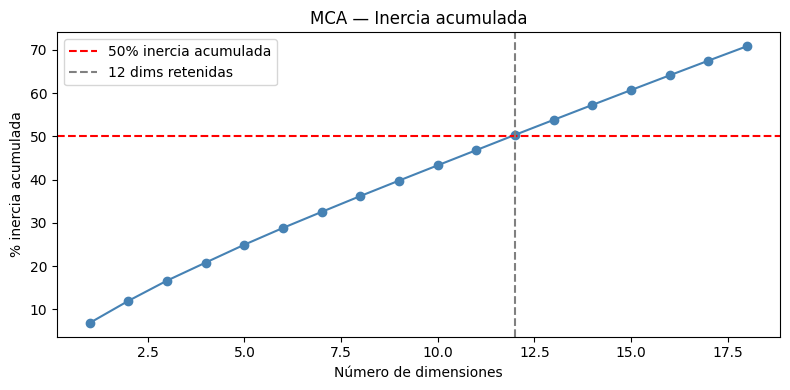

In [ ]:
# ============================================================
# BLOQUE 11 — MCA sobre variables categóricas
# ============================================================
# Retención de dimensiones: criterio ≥ 50% inercia acumulada,
# mínimo 2 dimensiones. Mismo criterio que el código anterior.

import prince

df_mca_input = df_vi[VARS_MCA].astype(str)  # prince requiere strings

n_comp = min(20, len(VARS_MCA) * 2)
mca = prince.MCA(n_components=n_comp, random_state=SEED)
mca.fit(df_mca_input)
coords_full = mca.row_coordinates(df_mca_input)

eigen_summary = mca.eigenvalues_summary
print("Inercia por dimensión:\n")
print(eigen_summary.to_string())

try:
    inercia_acum = (
        eigen_summary["% of variance (cumulative)"]
        .str.replace("%", "").astype(float).values / 100
    )
except KeyError:
    inercia_acum = eigen_summary.iloc[:, 2].str.replace("%", "").astype(float).values / 100

n_dims = min(max(int(np.searchsorted(inercia_acum, 0.50)) + 1, 2), n_comp)
print(f"\nDimensiones retenidas (≥50% inercia): {n_dims}")

coords = coords_full.iloc[:, :n_dims].copy()
coords.columns = [f"Dim{i+1}" for i in range(n_dims)]
coords.index = df_vi.index

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(inercia_acum)+1), inercia_acum*100, marker="o", color="steelblue")
plt.axhline(50, color="red", linestyle="--", label="50% inercia acumulada")
plt.axvline(n_dims, color="gray", linestyle="--", label=f"{n_dims} dims retenidas")
plt.xlabel("Número de dimensiones")
plt.ylabel("% inercia acumulada")
plt.title("MCA — Inercia acumulada")
plt.legend(); plt.tight_layout()
plt.savefig("mca_inercia.png", dpi=150); plt.show()

In [ ]:
# ============================================================
# BLOQUE 12 — Continuas estandarizadas + matriz final GMM
# ============================================================
# X_gmm = [coordenadas_MCA | continuas_estandarizadas]
# EXCLUYE area, dominio_macro y tamano_poblacional.
#
# IMPORTANTE — Por qué pueden aparecer NaN aquí:
#   Pueden quedar NaN residuales en variables continuas construidas o
#   recodificadas (por ejemplo, nivel_educativo_ord). dificultad_pago_credito
#   no forma parte de VARS_CONT ni de X_gmm.
#   GaussianMixture no acepta NaN → se imputan aquí con mediana antes
#   de escalar, y se reporta cuántos casos se afectaron.

from sklearn.preprocessing import StandardScaler

# --- Diagnóstico de NaN en VARS_CONT ---
cont_vals_raw = df_vi[VARS_CONT].astype(float)
nan_por_col = cont_vals_raw.isnull().sum()
if nan_por_col.sum() > 0:
    print('⚠ NaN detectados en variables continuas antes de escalar:')
    print(nan_por_col[nan_por_col > 0].to_string())
    print()

# --- Imputación de rescate con mediana (por columna) ---
cont_vals_imp = cont_vals_raw.copy()
for col in cont_vals_imp.columns:
    n_nan = cont_vals_imp[col].isnull().sum()
    if n_nan > 0:
        med = cont_vals_imp[col].median()
        cont_vals_imp[col] = cont_vals_imp[col].fillna(med)
        print(f'  [{col}] {n_nan} NaN → mediana = {med:.4f}')

# --- NaN en coordenadas MCA ---
nan_mca = np.isnan(coords.values).sum()
if nan_mca > 0:
    print(f'⚠ NaN en coordenadas MCA: {nan_mca} — reemplazando con 0.0')
    coords_clean = pd.DataFrame(
        np.nan_to_num(coords.values, nan=0.0),
        columns=coords.columns, index=coords.index
    )
else:
    coords_clean = coords.copy()

# --- Escalar continuas ---
scaler_cont = StandardScaler()
cont_scaled = scaler_cont.fit_transform(cont_vals_imp)
df_cont_scaled = pd.DataFrame(
    cont_scaled,
    columns=[f'{v}_sc' for v in VARS_CONT],
    index=df_vi.index,
)

# --- Concatenar MCA + continuas ---
X_gmm = np.hstack([
    coords_clean.values,
    df_cont_scaled.values,
])

# --- Verificación final: 0 NaN ---
n_nan_final = np.isnan(X_gmm).sum()
if n_nan_final > 0:
    print(f'⚠ NaN residuales en X_gmm ({n_nan_final}) → reemplazando con 0.0 (media escalada)')
    X_gmm = np.nan_to_num(X_gmm, nan=0.0)
else:
    print('✔ X_gmm sin NaN — listo para GMM')

print(f'\nMatriz GMM: {X_gmm.shape}')
print(f'  Dims MCA      : {coords_clean.shape[1]}')
print(f'  Vars continuas: {df_cont_scaled.shape[1]}')
print(f'  Total columnas: {X_gmm.shape[1]}')
print('\n⚠ Geografía (area, dominio_macro, tamano_poblacional) excluida de X_gmm')


⚠ NaN detectados en variables continuas antes de escalar:
nivel_educativo_ord    13

  [nivel_educativo_ord] 13 NaN → mediana = 4.0000
✔ X_gmm sin NaN — listo para GMM

Matriz GMM: (29954, 17)
  Dims MCA      : 12
  Vars continuas: 5
  Total columnas: 17

⚠ Geografía (area, dominio_macro, tamano_poblacional) excluida de X_gmm


Score Vi construido ✔
Indicadores usados (6): ['ingreso', 'nivel_educativo_ord', 'informalidad', 'nbi_score', 'empleo_vulnerable', 'acceso_digital']

Estadísticas Vi:
count    29954.000
mean         0.491
std          0.160
min          0.105
25%          0.366
50%          0.564
75%          0.617
max          0.917
Name: Vi, dtype: float64


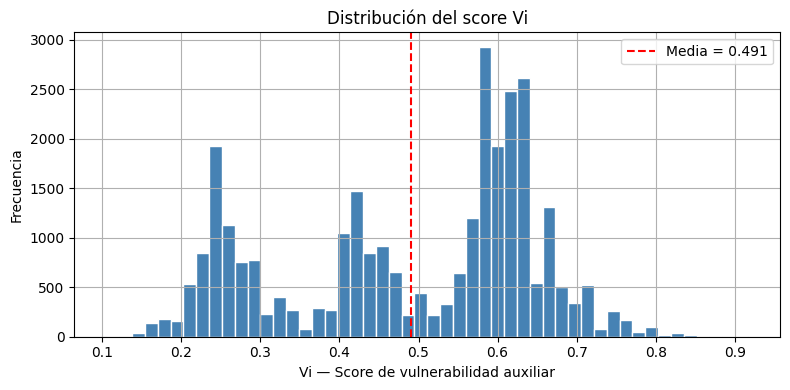

In [ ]:
# ============================================================
# BLOQUE 13 — Score auxiliar Vi
# ============================================================
# Vi es un score auxiliar de vulnerabilidad que sirve como:
#   1. Ancla para calcular Rk por perfil GMM
#   2. Insumo indirecto del IVF probabilístico vía Rk
#   3. No es la variable dependiente del XGBoost Regressor:
#      en el Bloque 24 la dependiente es IVF.
#
# Indicadores usados en Vi:
#   ingreso, nivel_educativo_ord, informalidad, nbi_score,
#   empleo_vulnerable y acceso_digital.
#   Las variables invertidas son aquellas donde valores más altos implican
#   menor vulnerabilidad: ingreso, educación y acceso digital.
#
# dificultad_pago_credito se evaluó en el Bloque 8, pero no ingresa al
# Vi final por variabilidad nula/baja en la base analítica.
# nivel_educativo_ord se usa aquí (no el categórico).

from sklearn.preprocessing import MinMaxScaler

scaler_vi = MinMaxScaler()

indicadores_vi = {
    "ingreso"              : True,   # invertir: más ingreso = menos vulnerable
    "nivel_educativo_ord"  : True,   # invertir: más educación = menos vulnerable
    "informalidad"         : False,  # directo
    "nbi_score"            : False,  # directo
    "empleo_vulnerable"    : False,  # directo
    "acceso_digital"       : True,   # invertir
}
# Filtrar solo los que están en df_vi
indicadores_vi = {k: v for k, v in indicadores_vi.items() if k in df_vi.columns}

cols_norm = []
for ind, invertir in indicadores_vi.items():
    col_norm = f"{ind}_norm"
    vals = df_vi[[ind]].astype(float)
    df_vi[col_norm] = scaler_vi.fit_transform(vals)
    if invertir:
        df_vi[col_norm] = 1 - df_vi[col_norm]
    cols_norm.append(col_norm)

df_vi["Vi"] = df_vi[cols_norm].mean(axis=1)

print("Score Vi construido ✔")
print(f"Indicadores usados ({len(cols_norm)}): {list(indicadores_vi.keys())}")
print(f"\nEstadísticas Vi:\n{df_vi['Vi'].describe().round(3)}")

plt.figure(figsize=(8, 4))
df_vi["Vi"].hist(bins=50, color="steelblue", edgecolor="white")
plt.axvline(df_vi["Vi"].mean(), color="red", linestyle="--",
            label=f"Media = {df_vi['Vi'].mean():.3f}")
plt.xlabel("Vi — Score de vulnerabilidad auxiliar")
plt.ylabel("Frecuencia")
plt.title("Distribución del score Vi")
plt.legend(); plt.tight_layout()
plt.savefig("distribucion_vi.png", dpi=150); plt.show()

In [ ]:
# ============================================================
# BLOQUE 14 — Pesos de expansión FAC500A
# ============================================================
# Este bloque solo prepara el factor de expansión. No realiza remuestreo.
# FAC500A se usa en entropía/ICL aproximado, Rk, IVF medio y tablas
# poblacionales; el GMM se ajusta directamente sobre X_gmm.

factor_raw = pd.to_numeric(df_vi["factor_expansion"], errors="coerce").values
factor_raw = np.nan_to_num(factor_raw, nan=1.0)
factor_raw = np.clip(factor_raw, 1e-6, None)
weights    = factor_raw / factor_raw.sum()

print(f"FAC500A — min: {factor_raw.min():.1f} | max: {factor_raw.max():.1f} | suma: {factor_raw.sum():,.0f}")

FAC500A — min: 0.7 | max: 2707.7 | suma: 9,243,595


Comparación de modelos GMM (fit directo sobre X_gmm; entropía/ICL ponderados por FAC500A):

    K           BIC           ICL    Entropia     E/ln(K)  conv
    2      10,526.1      10,602.0      0.0013      0.0018  True
    3    -295,630.9    -295,501.6      0.0022      0.0020  True
    4    -500,435.8    -500,341.3      0.0016      0.0011  True
    5    -604,821.4    -604,423.0      0.0066      0.0041  True

→ K seleccionado por ICL : 5
  K seleccionado por BIC : 5


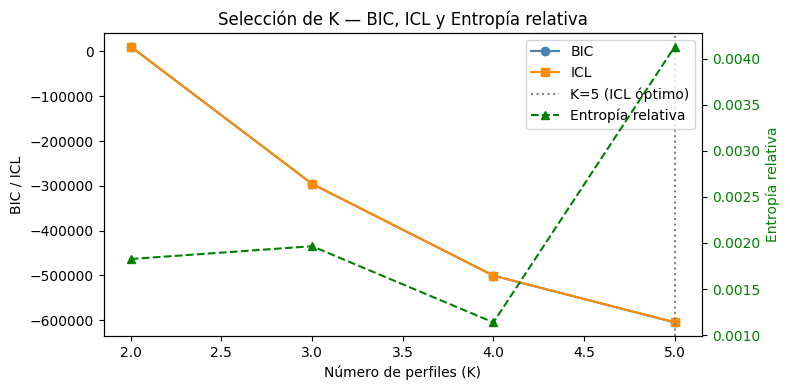

In [ ]:
# ============================================================
# BLOQUE 15 — Selección de K con BIC, ICL y Entropía
# ============================================================
# Se evalúan K = 2..5 perfiles latentes.
# Criterio principal de selección: ICL (Biernacki et al., 2000),
# que penaliza el BIC por la incertidumbre de clasificación (entropía).
# Criterio de calidad: entropía relativa E/ln(K) < 0.15 (óptimo) o < 0.30 (aceptable).
#
# El GMM se ajusta directamente sobre la base individual procesada (X_gmm).
# FAC500A no entrena el GMM; solo pondera la entropía/ICL aproximado
# para evaluar la incertidumbre de clasificación en términos poblacionales.

from sklearn.mixture import GaussianMixture

# ---- Funciones auxiliares ----

def entropia_clasificacion(proba_matrix, sample_weights=None):
    """Entropía media de clasificación, opcionalmente ponderada por FAC500A."""
    p     = np.clip(proba_matrix, 1e-10, 1.0)
    ent_i = -np.sum(p * np.log(p), axis=1)
    if sample_weights is None:
        return float(np.mean(ent_i))
    sw = np.asarray(sample_weights)
    sw = sw / sw.sum()
    return float(np.sum(sw * ent_i))


def icl_aprox(bic_val, proba_matrix, n_original, sample_weights=None):
    """ICL aproximado = BIC + 2 * entropía total ponderada."""
    p     = np.clip(proba_matrix, 1e-10, 1.0)
    ent_i = -np.sum(p * np.log(p), axis=1)
    if sample_weights is None:
        ent_total = np.sum(ent_i)
    else:
        sw        = np.asarray(sample_weights) / np.asarray(sample_weights).sum()
        ent_total = n_original * np.sum(sw * ent_i)
    return bic_val + 2 * ent_total


# ---- Comparación K = 2..6 ----
resultados = []

print("Comparación de modelos GMM (fit directo sobre X_gmm; entropía/ICL ponderados por FAC500A):\n")
print(f"  {'K':>3}  {'BIC':>12}  {'ICL':>12}  {'Entropia':>10}  {'E/ln(K)':>10}  conv")

for k in range(2, 6):
    gmm_k = GaussianMixture(
        n_components=k, covariance_type="full",
        random_state=SEED, n_init=10
    )
    gmm_k.fit(X_gmm)                       # ← fit directo sobre los datos originales

    proba_k  = gmm_k.predict_proba(X_gmm)
    bic_k    = gmm_k.bic(X_gmm)            # ← BIC sobre los mismos datos del fit
    entr_k   = entropia_clasificacion(proba_k, sample_weights=factor_raw)
    icl_k    = icl_aprox(bic_k, proba_k, len(X_gmm), sample_weights=factor_raw)
    entr_rel = entr_k / np.log(k)

    resultados.append({
        "K": k, "BIC": bic_k, "ICL": icl_k,
        "Entropia": entr_k, "Entr_rel": entr_rel,
        "converged": gmm_k.converged_,
        "_gmm": gmm_k,                      # ← ya no hace falta guardar "_Xw"
    })

    print(f"  {k:>3}  {bic_k:>12,.1f}  {icl_k:>12,.1f}  "
          f"{entr_k:>10.4f}  {entr_rel:>10.4f}  {gmm_k.converged_}")

crit_df    = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                            for r in resultados])
best_k     = int(crit_df.loc[crit_df["ICL"].idxmin(), "K"])
best_k_bic = int(crit_df.loc[crit_df["BIC"].idxmin(), "K"])

print(f"\n→ K seleccionado por ICL : {best_k}")
print(f"  K seleccionado por BIC : {best_k_bic}")
if best_k != best_k_bic:
    print("  ⚠ Discrepancia — se usa ICL como criterio principal (Biernacki et al., 2000)")

# Gráfico de criterios
fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.plot(crit_df["K"], crit_df["BIC"], marker="o", color="steelblue",  label="BIC")
ax1.plot(crit_df["K"], crit_df["ICL"], marker="s", color="darkorange", label="ICL")
ax2.plot(crit_df["K"], crit_df["Entr_rel"], marker="^", color="green",
         linestyle="--", label="Entropía relativa")
ax1.axvline(best_k, linestyle=":", color="gray", label=f"K={best_k} (ICL óptimo)")
ax1.set_xlabel("Número de perfiles (K)")
ax1.set_ylabel("BIC / ICL")
ax2.set_ylabel("Entropía relativa", color="green")
ax2.tick_params(axis="y", labelcolor="green")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.title("Selección de K — BIC, ICL y Entropía relativa")
plt.tight_layout()
plt.savefig("seleccion_k_gmm.png", dpi=150); plt.show()

In [ ]:
# ============================================================
# BLOQUE 16 — Ajuste final GMM y asignación de responsabilidades
# ============================================================
# Se ajusta el modelo final con K óptimo usando n_init=20 para mayor
# estabilidad. Las probabilidades posteriores P(perfil_k | i) son
# las "responsabilidades" del GMM para cada individuo.

# Se reestima el GMM final sobre X_gmm con n_init=20 para mayor estabilidad.
# No se reutiliza ni se genera una muestra remuestreada.
best_gmm = GaussianMixture(
    n_components=best_k, covariance_type="full",
    random_state=SEED, n_init=20
)
best_gmm.fit(X_gmm)                        # ← fit directo sobre X_gmm, sin remuestreo

labels      = best_gmm.predict(X_gmm)
proba_best  = best_gmm.predict_proba(X_gmm)

# Asignar perfiles a la base original
labels      = best_gmm.predict(X_gmm)
proba_best  = best_gmm.predict_proba(X_gmm)

probs = pd.DataFrame(
    proba_best,
    columns=[f"P_perfil_{k+1}" for k in range(best_k)],
    index=coords.index,
)

entr_final  = entropia_clasificacion(proba_best, sample_weights=factor_raw)
bic_final   = best_gmm.bic(X_gmm)
icl_final   = icl_aprox(bic_final, proba_best, len(X_gmm), sample_weights=factor_raw)
entr_rel_f  = entr_final / np.log(best_k)

calidad = (
    "✔ Óptima (< 0.15)"    if entr_rel_f < 0.15 else
    "~ Aceptable (< 0.30)"  if entr_rel_f < 0.30 else
    "⚠ Alta — perfiles difusos"
)
print(f"Modelo final GMM  K = {best_k}:")
print(f"  Convergió             : {best_gmm.converged_}")
print(f"  BIC                   : {bic_final:,.1f}")
print(f"  ICL                   : {icl_final:,.1f}")
print(f"  Entropía media        : {entr_final:.4f}")
print(f"  Entropía relativa     : {entr_rel_f:.4f}  {calidad}")

print("\nDistribución de perfiles (muestra vs. población expandida):")
for k in range(best_k):
    mask  = labels == k
    n_obs = mask.sum()
    n_pob = factor_raw[mask].sum()
    print(f"  Perfil {k+1}: {n_obs:,} obs.  |  ~{n_pob:,.0f} personas en población")

Modelo final GMM  K = 5:
  Convergió             : True
  BIC                   : -627,028.6
  ICL                   : -623,086.5
  Entropía media        : 0.0658
  Entropía relativa     : 0.0409  ✔ Óptima (< 0.15)

Distribución de perfiles (muestra vs. población expandida):
  Perfil 1: 12,810 obs.  |  ~3,767,383 personas en población
  Perfil 2: 5,451 obs.  |  ~2,096,007 personas en población
  Perfil 3: 2,218 obs.  |  ~519,269 personas en población
  Perfil 4: 4,178 obs.  |  ~1,364,805 personas en población
  Perfil 5: 5,297 obs.  |  ~1,496,131 personas en población


PERFILADO DE LOS 5 PERFILES LATENTES

— nivel_educativo_cat (% dentro de cada perfil) —
nivel_educativo_cat  Inicial  Maestria_doc  Primaria_comp  Primaria_inc  Secundaria_comp  Secundaria_inc  Sin_nivel  Sup_no_univ_comp  Sup_no_univ_inc  Sup_univ_comp
perfil                                                                                                                                                               
1                        0.1           0.0           18.1          18.9             30.2            16.9        5.3               5.0              3.7            1.8
2                        0.1           0.1            6.8           7.1             40.7            22.9        3.6               5.8              9.3            3.5
3                        0.4           0.0           20.4          27.0             20.3            16.3       12.3               1.5              1.2            0.6
4                        0.0           0.1           13.4          12.1           

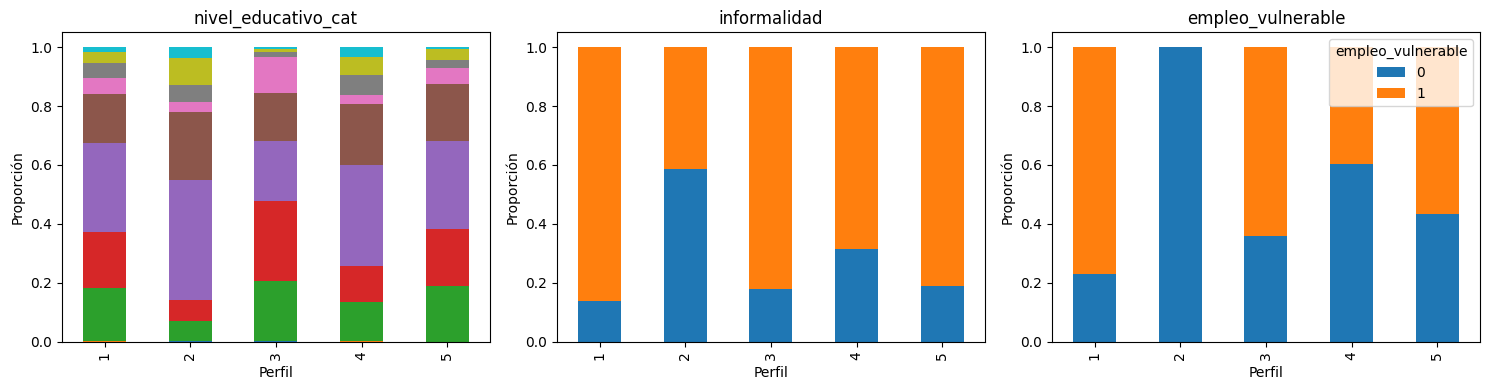


✔ Perfilado completo — variables retiradas de X_gmm; usadas para perfilado post-GMM (informalidad/empleo_vulnerable también participan en Vi/XGBoost)


In [ ]:
# ============================================================
# BLOQUE 16-BIS — Perfilado de clusters con variables retiradas
# ============================================================
# Las variables nivel_educativo_cat, informalidad y empleo_vulnerable
# se sacaron de X_gmm por redundancia con sus "variables padre"
# (nivel_educativo_ord y categoria_ocupacional respectivamente).
# Acá se usan para describir cada perfil latente: no fueron columnas
# del GMM, así que sirven como validación externa del perfilado.
# Precisión: informalidad y empleo_vulnerable sí participan en Vi,
# caracterización y modelos XGBoost, pero no en la formación de clusters.
#
# Se incluye también estado_civil y edad (asociación 0.61, real pero
# no redundante) para enriquecer la narrativa de cada perfil.

from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Cramér's V con corrección de sesgo (Bergsma, 2013)."""
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla, correction=False)[0]
    n = tabla.sum().sum()
    r, k = tabla.shape
    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - (r - 1) * (k - 1) / (n - 1))
    r_corr = r - (r - 1) ** 2 / (n - 1)
    k_corr = k - (k - 1) ** 2 / (n - 1)
    denom = min(r_corr - 1, k_corr - 1)
    if denom <= 0:
        return np.nan
    return np.sqrt(phi2_corr / denom)


df_perfil = df_vi.copy()
df_perfil["perfil"] = labels + 1  # 1-indexado para reportes

print("=" * 70)
print(f"PERFILADO DE LOS {best_k} PERFILES LATENTES")
print("=" * 70)

# --- Variables categóricas retiradas (% por perfil) ---
for var in VARS_PERFILADO_EXTRA:
    print(f"\n— {var} (% dentro de cada perfil) —")
    tabla = pd.crosstab(df_perfil["perfil"], df_perfil[var], normalize="index")
    print((tabla * 100).round(1).to_string())

# --- estado_civil y edad: contexto adicional no usado en X_gmm como tal ---
print(f"\n— estado_civil (% dentro de cada perfil) —")
tabla_ec = pd.crosstab(df_perfil["perfil"], df_perfil["estado_civil"], normalize="index")
print((tabla_ec * 100).round(1).to_string())

print(f"\n— edad (estadísticos por perfil) —")
print(df_perfil.groupby("perfil")["edad"].agg(["mean", "median", "std"]).round(1).to_string())

# --- Resumen de variables continuas clave usadas en X_gmm, para contexto ---
print(f"\n— Variables de X_gmm por perfil (medias) —")
print(df_perfil.groupby("perfil")[VARS_CONT].mean().round(2).to_string())

# --- Validación cruzada de redundancia: ¿el perfil separa bien estas
#     variables aunque no las haya visto? (Cramér's V perfil vs. cada extra) ---
print(f"\n— Validación: asociación perfil ↔ variables NO usadas en X_gmm —")
for var in VARS_PERFILADO_EXTRA + ["estado_civil"]:
    v = cramers_v(df_perfil["perfil"], df_perfil[var])
    print(f"  Cramér's V (perfil ↔ {var}): {v:.3f}")

# --- Visualización: barras apiladas por perfil para las 3 variables extra ---
fig, axes = plt.subplots(1, len(VARS_PERFILADO_EXTRA), figsize=(5 * len(VARS_PERFILADO_EXTRA), 4))
if len(VARS_PERFILADO_EXTRA) == 1:
    axes = [axes]
for ax, var in zip(axes, VARS_PERFILADO_EXTRA):
    tabla = pd.crosstab(df_perfil["perfil"], df_perfil[var], normalize="index")
    tabla.plot(kind="bar", stacked=True, ax=ax, legend=(var == VARS_PERFILADO_EXTRA[-1]))
    ax.set_title(var)
    ax.set_xlabel("Perfil")
    ax.set_ylabel("Proporción")
plt.tight_layout()
plt.savefig("perfilado_variables_extra.png", dpi=150)
plt.show()

print(f"\n✔ Perfilado completo — variables retiradas de X_gmm; usadas para perfilado post-GMM (informalidad/empleo_vulnerable también participan en Vi/XGBoost)")


In [ ]:
# ============================================================
# BLOQUE 17 — Cálculo de Rk por perfil
# ============================================================
# Rk = promedio PONDERADO de Vi dentro del perfil k, usando FAC500A.
#
# La ponderación es necesaria porque Rk debe reflejar la vulnerabilidad
# real del perfil en la población peruana, no solo en la muestra.
# Un promedio simple sesgaría Rk hacia los estratos sobremuestreados
# (e.g. zonas rurales), distorsionando el IVF de todos los individuos
# asignados a ese perfil.
#
# Referencia: Vermunt & Magidson (2002) — Latent class cluster analysis.

df_final = df_vi.copy()
df_final["perfil_dominante"] = labels
df_final["factor_raw"]       = factor_raw
df_final = pd.concat(
    [df_final.reset_index(drop=True), probs.reset_index(drop=True)], axis=1
)

print("Vulnerabilidad promedio ponderada por perfil (Rk):")
rk = {}
for k in range(best_k):
    mask  = df_final["perfil_dominante"] == k
    vi_k  = df_final.loc[mask, "Vi"].values
    w_k   = factor_raw[mask]
    rk[k] = np.average(vi_k, weights=w_k)
    print(f"  Perfil {k+1}: Rk = {rk[k]:.4f}  "
          f"({mask.sum():,} obs.  |  ~{w_k.sum():,.0f} en población)")

# Ordenar perfiles de mayor a menor vulnerabilidad (para interpretación)
rk_ordenado = sorted(rk.items(), key=lambda x: x[1], reverse=True)
print("\nOrden de vulnerabilidad (mayor → menor):")
for k, val in rk_ordenado:
    print(f"  Perfil {k+1}: Rk = {val:.4f}")

Vulnerabilidad promedio ponderada por perfil (Rk):
  Perfil 1: Rk = 0.5188  (12,810 obs.  |  ~3,767,383 en población)
  Perfil 2: Rk = 0.3133  (5,451 obs.  |  ~2,096,007 en población)
  Perfil 3: Rk = 0.5951  (2,218 obs.  |  ~519,269 en población)
  Perfil 4: Rk = 0.4357  (4,178 obs.  |  ~1,364,805 en población)
  Perfil 5: Rk = 0.5151  (5,297 obs.  |  ~1,496,131 en población)

Orden de vulnerabilidad (mayor → menor):
  Perfil 3: Rk = 0.5951
  Perfil 1: Rk = 0.5188
  Perfil 5: Rk = 0.5151
  Perfil 4: Rk = 0.4357
  Perfil 2: Rk = 0.3133


IVF construido ✔

Estadísticas IVF:
count    29954.0000
mean         0.4747
std          0.0845
min          0.3133
25%          0.4357
50%          0.5160
75%          0.5188
max          0.5951
Name: IVF, dtype: float64


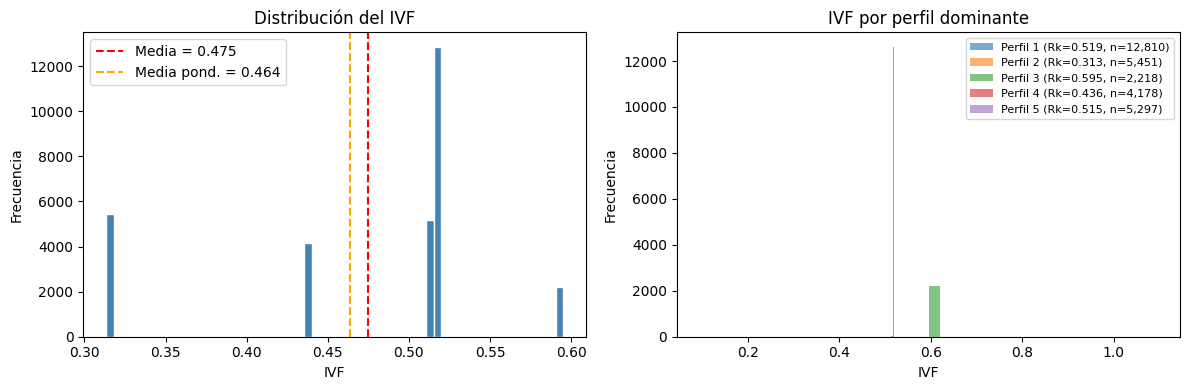

In [ ]:
# ============================================================
# BLOQUE 18 — Construcción del IVF
# ============================================================
# IVF_i = Σ_k [ P(perfil_k | i) × Rk ]
#
# La suma sobre los K perfiles garantiza que individuos en la
# frontera entre perfiles reciban un IVF interpolado, evitando
# la asignación dura (hard clustering).
# Fuente: Fraley & Raftery (2002) — Model-based clustering.

ivf = np.zeros(len(df_final))
for k in range(best_k):
    ivf += df_final[f"P_perfil_{k+1}"].values * rk[k]
df_final["IVF"] = ivf

print(f"IVF construido ✔")
print(f"\nEstadísticas IVF:\n{df_final['IVF'].describe().round(4)}")

# Distribución general del IVF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma general
axes[0].hist(df_final["IVF"], bins=60, color="steelblue", edgecolor="white")
axes[0].axvline(df_final["IVF"].mean(), color="red", linestyle="--",
                label=f"Media = {df_final['IVF'].mean():.3f}")
axes[0].axvline(np.average(df_final["IVF"], weights=factor_raw),
                color="orange", linestyle="--",
                label=f"Media pond. = {np.average(df_final['IVF'], weights=factor_raw):.3f}")
axes[0].set_xlabel("IVF"); axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución del IVF"); axes[0].legend()

# Por perfil
colors = plt.cm.tab10.colors
for k in range(best_k):
    sub = df_final[df_final["perfil_dominante"] == k]["IVF"]
    axes[1].hist(sub, bins=40, alpha=0.6,
                 label=f"Perfil {k+1} (Rk={rk[k]:.3f}, n={len(sub):,})",
                 color=colors[k])
axes[1].set_xlabel("IVF"); axes[1].set_ylabel("Frecuencia")
axes[1].set_title("IVF por perfil dominante")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("distribucion_ivf.png", dpi=150); plt.show()

Caracterización socioeconómica de perfiles (estadísticas ponderadas por FAC500A):

Perfil                 Perfil 1      Perfil 2     Perfil 3      Perfil 4      Perfil 5
n_muestra          1.281000e+04  5.451000e+03    2218.0000  4.178000e+03  5.297000e+03
n_poblacion        3.767382e+06  2.096006e+06  519269.0000  1.364805e+06  1.496130e+06
IVF_medio          5.185000e-01  3.133000e-01       0.5951  4.359000e-01  5.150000e-01
Vi_medio           5.188000e-01  3.133000e-01       0.5951  4.357000e-01  5.151000e-01
Rk                 5.188000e-01  3.133000e-01       0.5951  4.357000e-01  5.151000e-01
ingreso_med        6.240000e+02  1.037500e+03     569.8000  1.089900e+03  5.854000e+02
edad_media         4.410000e+01  3.110000e+01      43.4000  4.050000e+01  3.880000e+01
nbi_medio          0.000000e+00  0.000000e+00       0.4190  3.530000e-01  9.220000e-01
pct_informal       8.290000e-01  3.940000e-01       0.7700  6.840000e-01  7.790000e-01
pct_emp_vuln       7.240000e-01  0.000000e+00  

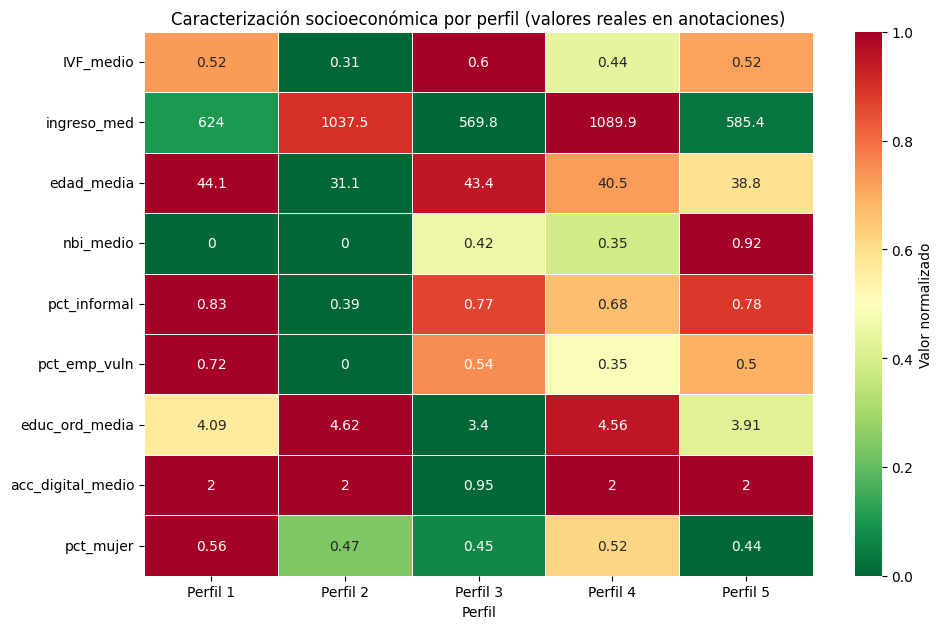


✔ estadisticas_perfiles.csv exportado


In [ ]:
# ============================================================
# BLOQUE 19 — Caracterización socioeconómica de perfiles
# ============================================================
# Estadísticas ponderadas por FAC500A para que los promedios
# representen la población, no la muestra.

def prom_pond(serie, pesos):
    """Promedio ponderado ignorando NaN."""
    mask = ~np.isnan(serie.astype(float))
    if mask.sum() == 0:
        return np.nan
    return np.average(serie.astype(float)[mask], weights=pesos[mask])

rows = []
for k in range(best_k):
    mask = df_final["perfil_dominante"] == k
    sub  = df_final[mask].reset_index(drop=True)
    w    = sub["factor_raw"].values

    # Proporción ponderada de sexo
    pct_mujer = prom_pond((sub["sexo"] == "Mujer").astype(float), w)

    rows.append({
        "Perfil"            : f"Perfil {k+1}",
        "n_muestra"         : mask.sum(),
        "n_poblacion"       : int(w.sum()),
        "IVF_medio"         : round(prom_pond(sub["IVF"], w), 4),
        "Vi_medio"          : round(prom_pond(sub["Vi"],  w), 4),
        "Rk"                : round(rk[k], 4),
        "ingreso_med"       : round(prom_pond(sub["ingreso"], w), 1),
        "edad_media"        : round(prom_pond(sub["edad"],    w), 1),
        "nbi_medio"         : round(prom_pond(sub["nbi_score"], w), 3),
        "pct_informal"      : round(prom_pond(sub["informalidad"].astype(float), w), 3),
        "pct_emp_vuln"      : round(prom_pond(sub["empleo_vulnerable"].astype(float), w), 3),
        "educ_ord_media"    : round(prom_pond(sub["nivel_educativo_ord"].astype(float), w), 2),
        "acc_digital_medio" : round(prom_pond(sub["acceso_digital"].astype(float), w), 3) if "acceso_digital" in sub.columns else np.nan,
        "pct_mujer"         : round(pct_mujer, 3),
    })

stats_perfil = pd.DataFrame(rows).set_index("Perfil")
print("Caracterización socioeconómica de perfiles (estadísticas ponderadas por FAC500A):\n")
print(stats_perfil.T.to_string())

# Heatmap de caracterización
vars_heatmap = ["IVF_medio","ingreso_med","edad_media","nbi_medio",
                "pct_informal","pct_emp_vuln","educ_ord_media","acc_digital_medio","pct_mujer"]
vars_heatmap = [v for v in vars_heatmap if v in stats_perfil.columns]

df_heat = stats_perfil[vars_heatmap].T
df_heat_norm = (df_heat - df_heat.min(axis=1).values.reshape(-1,1)) / \
               (df_heat.max(axis=1) - df_heat.min(axis=1) + 1e-9).values.reshape(-1,1)

fig, ax = plt.subplots(figsize=(max(6, best_k * 2), len(vars_heatmap) * 0.6 + 1))
sns.heatmap(df_heat_norm, annot=df_heat.round(2), fmt="g",
            cmap="RdYlGn_r", ax=ax, linewidths=0.5, cbar_kws={"label": "Valor normalizado"})
ax.set_title("Caracterización socioeconómica por perfil (valores reales en anotaciones)")
plt.tight_layout()
plt.savefig("heatmap_perfiles_socioeconomico.png", dpi=150); plt.show()

stats_perfil.to_csv("estadisticas_perfiles.csv")
print("\n✔ estadisticas_perfiles.csv exportado")


Distribución por area (% ponderado por FAC500A dentro de cada perfil):
        Perfil 1  Perfil 2  Perfil 3  Perfil 4  Perfil 5
Urbano     0.772     0.886     0.607     0.837     0.676
Rural      0.228     0.114     0.393     0.163     0.324


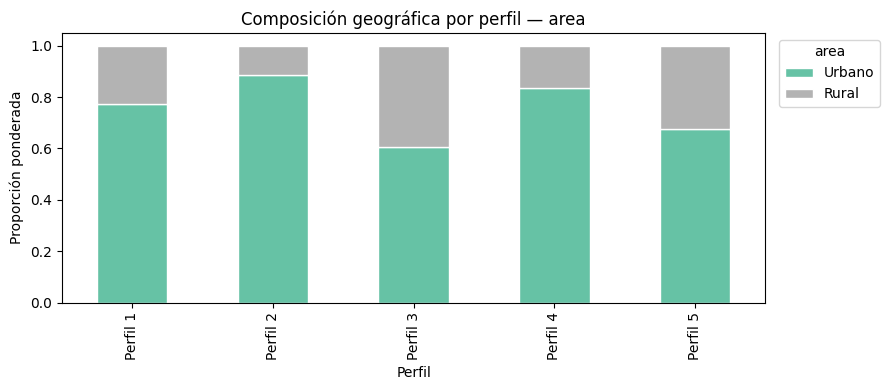


Distribución por dominio_macro (% ponderado por FAC500A dentro de cada perfil):
                    Perfil 1  Perfil 2  Perfil 3  Perfil 4  Perfil 5
Sierra                 0.423     0.287     0.301     0.292     0.348
Selva                  0.105     0.079     0.296     0.187     0.271
Costa                  0.241     0.280     0.202     0.259     0.231
Lima Metropolitana     0.231     0.353     0.201     0.262     0.150


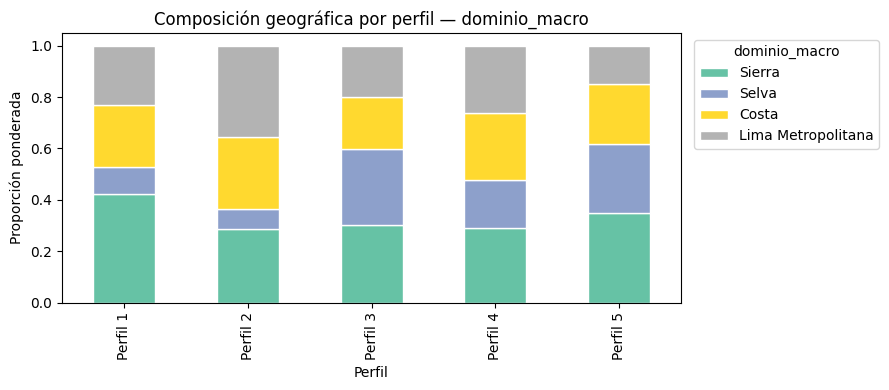


Distribución por tamano_poblacional (% ponderado por FAC500A dentro de cada perfil):
                Perfil 1  Perfil 2  Perfil 3  Perfil 4  Perfil 5
Ciudad mediana     0.125     0.120     0.076     0.140     0.133
CP pequeño         0.222     0.182     0.184     0.159     0.201
Rural              0.228     0.114     0.393     0.163     0.324
Ciudad grande      0.425     0.584     0.347     0.539     0.342


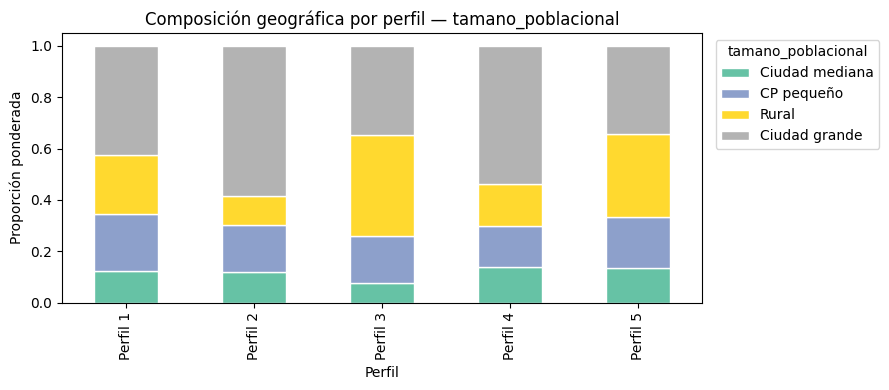


IVF medio ponderado por dominio_macro:
  Sierra               IVF = 0.4738  (~3,270,441 personas)
  Selva                IVF = 0.4858  (~1,376,712 personas)
  Costa                IVF = 0.4564  (~2,300,288 personas)
  Lima Metropolitana   IVF = 0.4426  (~2,296,154 personas)


In [ ]:
# ============================================================
# BLOQUE 20 — Caracterización territorial de perfiles
# ============================================================
# Distribución ponderada de cada perfil según:
#   area, dominio_macro, tamano_poblacional
#
# Este bloque responde: ¿los perfiles más vulnerables se concentran
# geográficamente en alguna región o tipo de área?
# La geografía no entra directamente a X_gmm ni al IVF final; caracteriza
# la distribución posterior. dominio/estrato solo fueron auxiliares en la
# imputación del ingreso.

VARS_GEO = [v for v in ["area", "dominio_macro", "tamano_poblacional"] if v in df_final.columns]

if not VARS_GEO:
    print("⚠ Variables geográficas no encontradas. Verificar Bloque 7.")
else:
    for geo_var in VARS_GEO:
        print(f"\n{'='*60}")
        print(f"Distribución por {geo_var} (% ponderado por FAC500A dentro de cada perfil):")
        print(f"{'='*60}")

        tabla = {}
        for k in range(best_k):
            mask = df_final["perfil_dominante"] == k
            sub  = df_final[mask]
            w    = sub["factor_raw"].values
            cats = sub[geo_var].values

            dist = {}
            for cat in pd.Series(cats).dropna().unique():
                m2       = cats == cat
                dist[cat] = w[m2].sum() / w.sum()
            tabla[f"Perfil {k+1}"] = dist

        df_geo = pd.DataFrame(tabla).fillna(0).round(3)
        print(df_geo.to_string())

        # Gráfico de barras apiladas
        fig, ax = plt.subplots(figsize=(max(6, best_k * 1.8), 4))
        df_geo.T.plot(kind="bar", stacked=True, ax=ax, colormap="Set2", edgecolor="white")
        ax.set_xlabel("Perfil"); ax.set_ylabel("Proporción ponderada")
        ax.set_title(f"Composición geográfica por perfil — {geo_var}")
        ax.legend(title=geo_var, bbox_to_anchor=(1.01, 1), loc="upper left")
        plt.tight_layout()
        plt.savefig(f"geo_{geo_var}_perfiles.png", dpi=150); plt.show()

    # IVF medio por dominio_macro (ponderado)
    if "dominio_macro" in df_final.columns:
        print("\nIVF medio ponderado por dominio_macro:")
        for dom in df_final["dominio_macro"].dropna().unique():
            mask = df_final["dominio_macro"] == dom
            ivf_dom = np.average(df_final.loc[mask, "IVF"], weights=factor_raw[mask])
            n_pob   = factor_raw[mask].sum()
            print(f"  {dom:<20} IVF = {ivf_dom:.4f}  (~{n_pob:,.0f} personas)")

XGBoost SIN geografía — desempeño:

              precision    recall  f1-score   support

    Perfil 1       0.87      0.94      0.90      2562
    Perfil 2       0.84      1.00      0.92      1090
    Perfil 3       1.00      1.00      1.00       444
    Perfil 4       0.96      0.38      0.55       836
    Perfil 5       0.81      0.87      0.84      1059

    accuracy                           0.87      5991
   macro avg       0.90      0.84      0.84      5991
weighted avg       0.88      0.87      0.85      5991



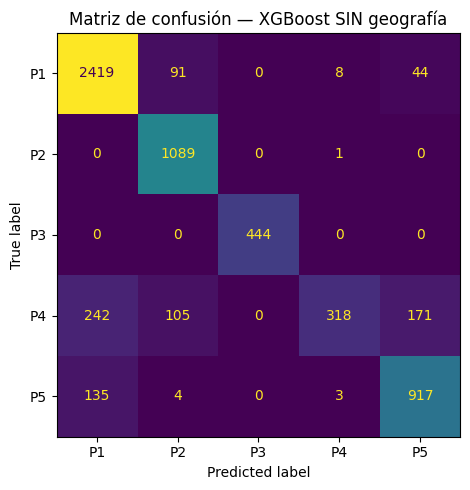

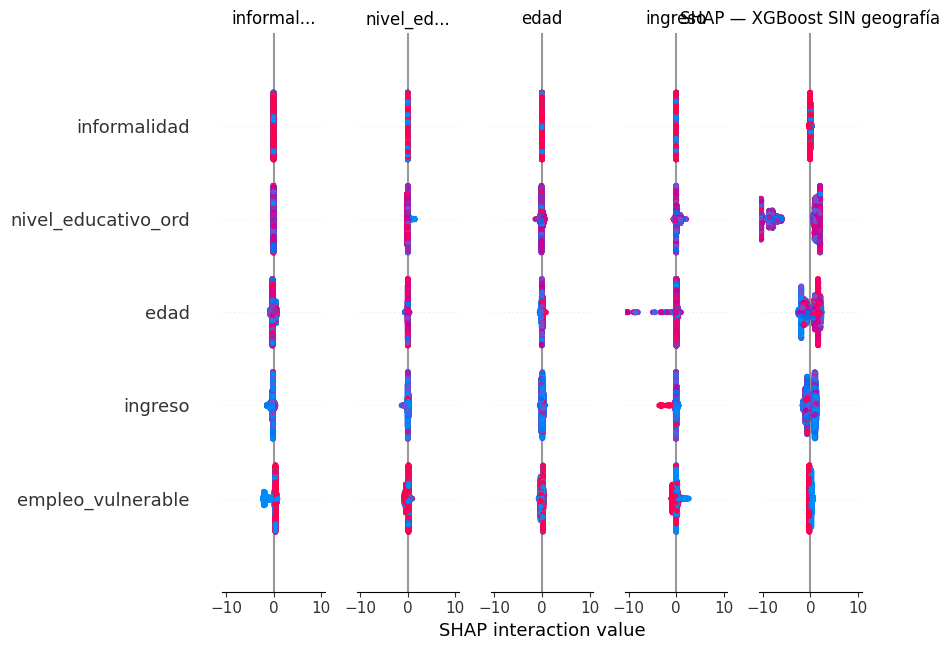


Variables usadas (13): ['sexo', 'edad', 'estado_civil', 'nivel_educativo_ord', 'informalidad', 'empleo_vulnerable', 'ingreso', 'nbi_score', 'categoria_ocupacional', 'sin_pension', 'acceso_digital', 'dificultad_pago_credito', 'etnia']


In [ ]:
# ============================================================
# BLOQUE 21 — XGBoost clasificador SIN geografía
# ============================================================
# Objetivo: identificar predictores socioeconómicos del perfil sin incluir
# variables geográficas. Esto aproxima el papel de características individuales
# sobre la clasificación latente.
#
# sample_weight = FAC500A usa el factor de expansión como peso poblacional;
# no equivale a modelar toda la varianza del diseño complejo
# (estratos/conglomerados) de la ENAHO.

import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

VARS_XGB_SIN_GEO = [
    "sexo", "edad", "estado_civil",
    "nivel_educativo_ord",
    "informalidad", "empleo_vulnerable",
    "ingreso", "nbi_score",
    "categoria_ocupacional",
    "sin_pension",
    "acceso_digital",
    "dificultad_pago_credito",
    "etnia",
]
VARS_XGB_SIN_GEO = [v for v in VARS_XGB_SIN_GEO if v in df_final.columns]

X_sin = pd.get_dummies(df_final[VARS_XGB_SIN_GEO], drop_first=True).astype(float)
y_xgb = df_final["perfil_dominante"].astype(int)
w_xgb = factor_raw   # FAC500A como sample_weight

X_tr_s, X_te_s, y_tr_s, y_te_s, w_tr_s, w_te_s = train_test_split(
    X_sin, y_xgb, w_xgb, test_size=0.2, random_state=SEED, stratify=y_xgb
)

model_sin = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    eval_metric="mlogloss", random_state=SEED, verbosity=0,
)
model_sin.fit(X_tr_s, y_tr_s, sample_weight=w_tr_s)

y_pred_s = model_sin.predict(X_te_s)
print("XGBoost SIN geografía — desempeño:\n")
print(classification_report(
    y_te_s, y_pred_s,
    target_names=[f"Perfil {k+1}" for k in range(best_k)]
))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_te_s, y_pred_s,
    display_labels=[f"P{k+1}" for k in range(best_k)],
    ax=ax, colorbar=False
)
ax.set_title("Matriz de confusión — XGBoost SIN geografía")
plt.tight_layout()
plt.savefig("confusion_sin_geo.png", dpi=150); plt.show()

# SHAP sin geografía
explainer_sin   = shap.TreeExplainer(model_sin)
shap_vals_sin   = explainer_sin.shap_values(X_te_s)

shap.summary_plot(
    shap_vals_sin, X_te_s,
    class_names=[f"Perfil {k+1}" for k in range(best_k)],
    show=False, plot_size=(10, 6)
)
plt.title("SHAP — XGBoost SIN geografía")
plt.tight_layout()
plt.savefig("shap_sin_geo.png", dpi=150, bbox_inches="tight"); plt.show()

print(f"\nVariables usadas ({len(VARS_XGB_SIN_GEO)}): {VARS_XGB_SIN_GEO}")

XGBoost CON geografía — desempeño:

              precision    recall  f1-score   support

    Perfil 1       0.86      0.95      0.90      2562
    Perfil 2       0.85      1.00      0.92      1090
    Perfil 3       1.00      1.00      1.00       444
    Perfil 4       0.97      0.38      0.55       836
    Perfil 5       0.81      0.86      0.84      1059

    accuracy                           0.87      5991
   macro avg       0.90      0.84      0.84      5991
weighted avg       0.88      0.87      0.85      5991



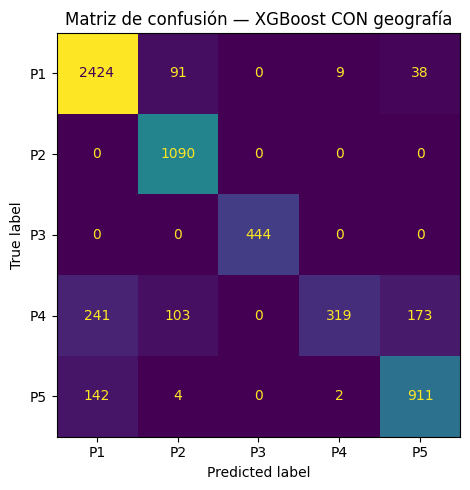

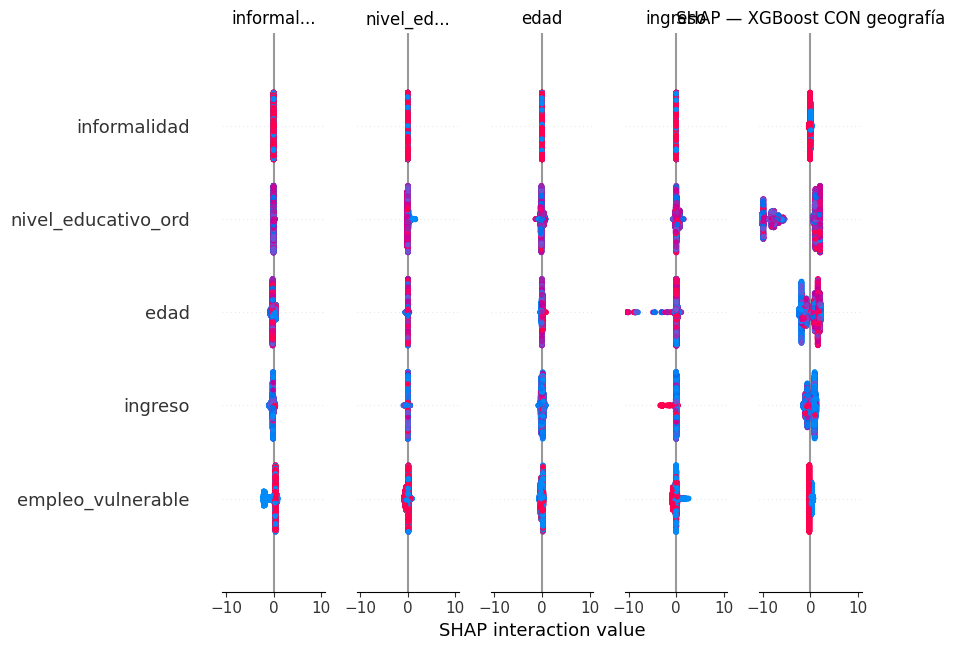

In [ ]:
# ============================================================
# BLOQUE 22 — XGBoost clasificador CON geografía
# ============================================================
# Se agregan area, dominio_macro y tamano_poblacional al modelo.
# La comparación con Bloque 21 muestra cuánto aportan las variables
# territoriales agregadas a la predicción del perfil.

VARS_XGB_CON_GEO = VARS_XGB_SIN_GEO + [
    "area", "dominio_macro", "tamano_poblacional"
]
VARS_XGB_CON_GEO = [v for v in VARS_XGB_CON_GEO if v in df_final.columns]

X_con = pd.get_dummies(df_final[VARS_XGB_CON_GEO], drop_first=True).astype(float)

X_tr_c, X_te_c, y_tr_c, y_te_c, w_tr_c, w_te_c = train_test_split(
    X_con, y_xgb, w_xgb, test_size=0.2, random_state=SEED, stratify=y_xgb
)

model_con = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    eval_metric="mlogloss", random_state=SEED, verbosity=0,
)
model_con.fit(X_tr_c, y_tr_c, sample_weight=w_tr_c)

y_pred_c = model_con.predict(X_te_c)
print("XGBoost CON geografía — desempeño:\n")
print(classification_report(
    y_te_c, y_pred_c,
    target_names=[f"Perfil {k+1}" for k in range(best_k)]
))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_te_c, y_pred_c,
    display_labels=[f"P{k+1}" for k in range(best_k)],
    ax=ax, colorbar=False
)
ax.set_title("Matriz de confusión — XGBoost CON geografía")
plt.tight_layout()
plt.savefig("confusion_con_geo.png", dpi=150); plt.show()

# SHAP con geografía
explainer_con = shap.TreeExplainer(model_con)
shap_vals_con = explainer_con.shap_values(X_te_c)

shap.summary_plot(
    shap_vals_con, X_te_c,
    class_names=[f"Perfil {k+1}" for k in range(best_k)],
    show=False, plot_size=(10, 6)
)
plt.title("SHAP — XGBoost CON geografía")
plt.tight_layout()
plt.savefig("shap_con_geo.png", dpi=150, bbox_inches="tight"); plt.show()

Importancia media SHAP — comparación sin/con geografía:

                                     Sin_geo  Con_geo
acceso_digital                        1.5042   1.5039
empleo_vulnerable                     0.9368   0.8987
nbi_score                             0.7978   0.7881
estado_civil_Conviviente              0.2196   0.2112
estado_civil_Soltero/a                0.1908   0.2186
categoria_ocupacional_Obrero          0.1395   0.1373
informalidad                          0.1321   0.1248
ingreso                               0.0915   0.0811
edad                                  0.0713   0.0749
estado_civil_Separado/a               0.0702   0.0583
nivel_educativo_ord                   0.0588   0.0525
categoria_ocupacional_Empleador       0.0579   0.0573
etnia                                 0.0512   0.0487
estado_civil_Viudo/a                  0.0445   0.0411
categoria_ocupacional_Trab_hogar      0.0370   0.0364
sin_pension                           0.0208   0.0176
sexo_Mujer               

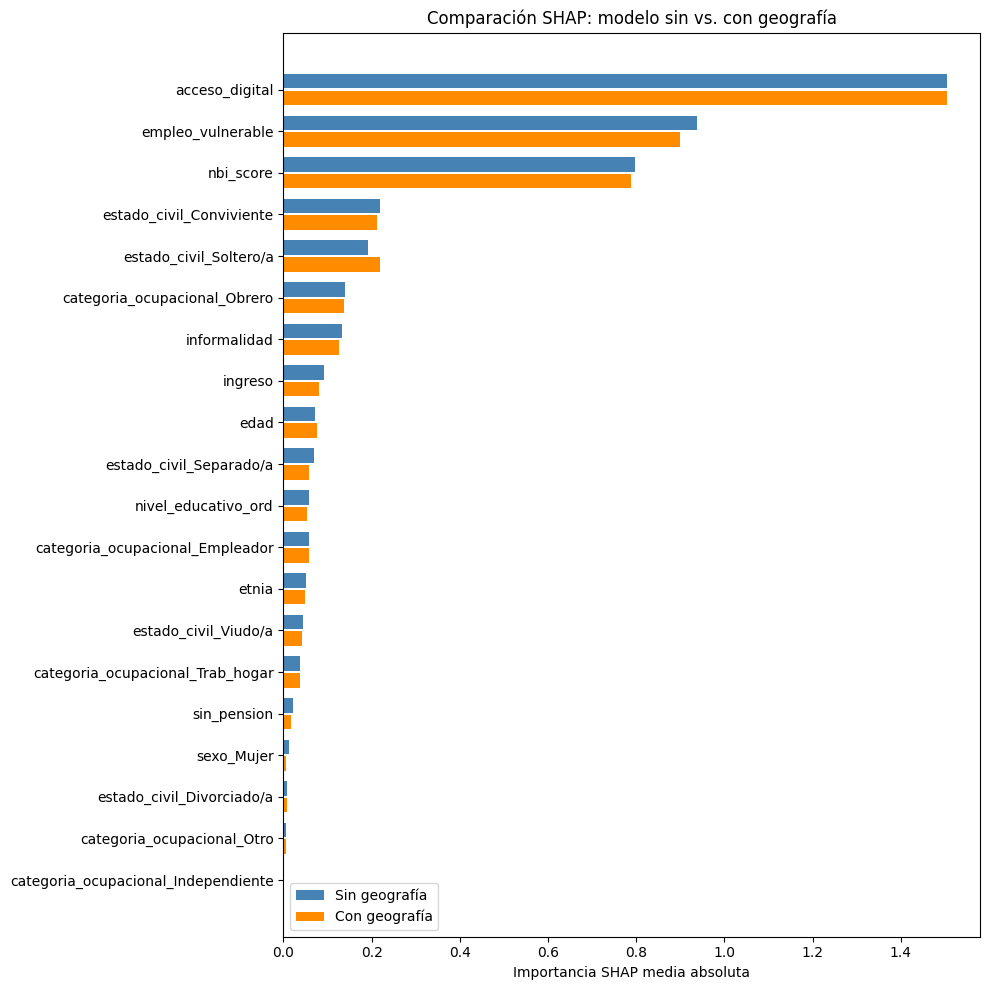

In [ ]:
# ============================================================
# BLOQUE 23 — Comparación SHAP sin/con geografía
# ============================================================
# Compara la importancia media de cada variable en ambos modelos.
# Permite responder:
#   1. ¿Cuánto cambia la importancia de las variables socioeconómicas
#      al agregar geografía?
#   2. ¿Qué tanto explica la geografía por sí sola?
#   3. ¿Las variables socioeconómicas son robustas al control geográfico?

def shap_mean_abs(shap_values_list, feature_names):
    """
    Importancia media absoluta SHAP agregada sobre todos los perfiles.
    shap_values_list: list de arrays (uno por clase) shape (n, p),
                      o array 3D shape (n_clases, n, p).
    """
    if isinstance(shap_values_list, list):
        # For list of arrays (num_classes, num_samples, num_features)
        arr = np.abs(np.stack(shap_values_list, axis=0)).mean(axis=(0, 1))
    else:
        # For 3D array (num_samples, num_features, num_classes)
        arr = np.abs(shap_values_list).mean(axis=(0, 2)) # Fix: average over samples (axis 0) and classes (axis 2)
    return pd.Series(arr, index=feature_names)

imp_sin = shap_mean_abs(shap_vals_sin, X_te_s.columns).rename("Sin_geo")
imp_con = shap_mean_abs(shap_vals_con, X_te_c.columns).rename("Con_geo")

# Alinear: variables comunes
vars_comunes = imp_sin.index.intersection(imp_con.index)
df_comp = pd.concat([imp_sin[vars_comunes], imp_con[vars_comunes]], axis=1).sort_values(
    "Sin_geo", ascending=False
)

# Variables geográficas (solo en modelo con geo)
vars_geo_cols = [c for c in imp_con.index if c not in imp_sin.index]

print("Importancia media SHAP — comparación sin/con geografía:\n")
print(df_comp.round(4).to_string())
if vars_geo_cols:
    print(f"\nVariables geográficas exclusivas del modelo con geo:")
    print(imp_con[vars_geo_cols].sort_values(ascending=False).round(4).to_string())

# Gráfico comparativo
top_n = min(20, len(df_comp))
df_plot = df_comp.head(top_n)

fig, ax = plt.subplots(figsize=(10, top_n * 0.45 + 1))
x  = np.arange(len(df_plot))
ax.barh(x - 0.2, df_plot["Sin_geo"], height=0.35, label="Sin geografía", color="steelblue")
ax.barh(x + 0.2, df_plot["Con_geo"],  height=0.35, label="Con geografía",  color="darkorange")
ax.set_yticks(x); ax.set_yticklabels(df_plot.index)
ax.set_xlabel("Importancia SHAP media absoluta")
ax.set_title("Comparación SHAP: modelo sin vs. con geografía")
ax.legend(); ax.invert_yaxis()
plt.tight_layout()
plt.savefig("shap_comparacion_geo.png", dpi=150); plt.show()

XGBoost Regressor — IVF como variable dependiente:
  RMSE : 0.0375
  R²   : 0.7996


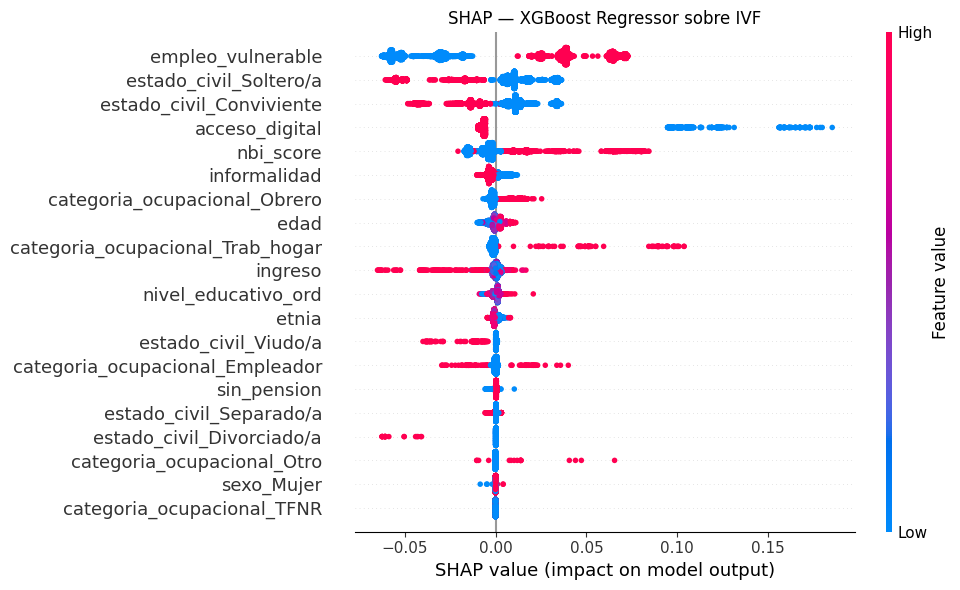

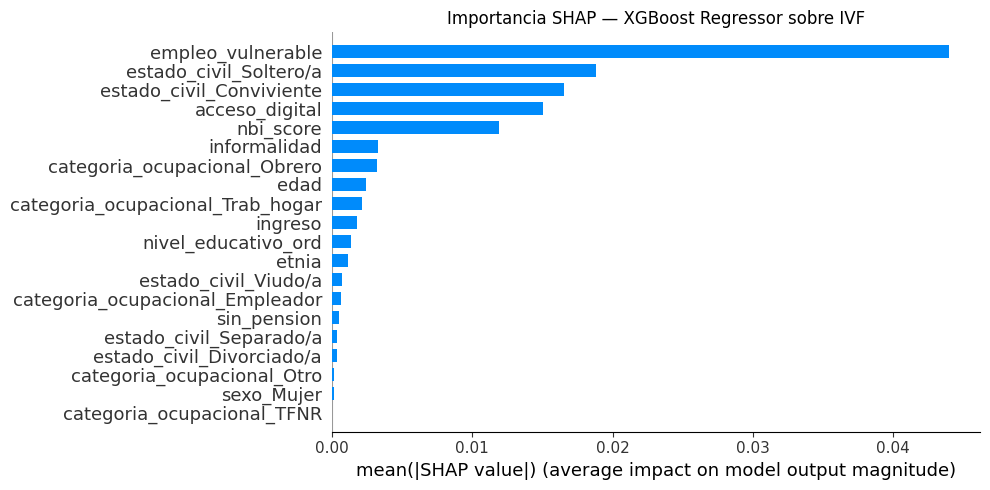

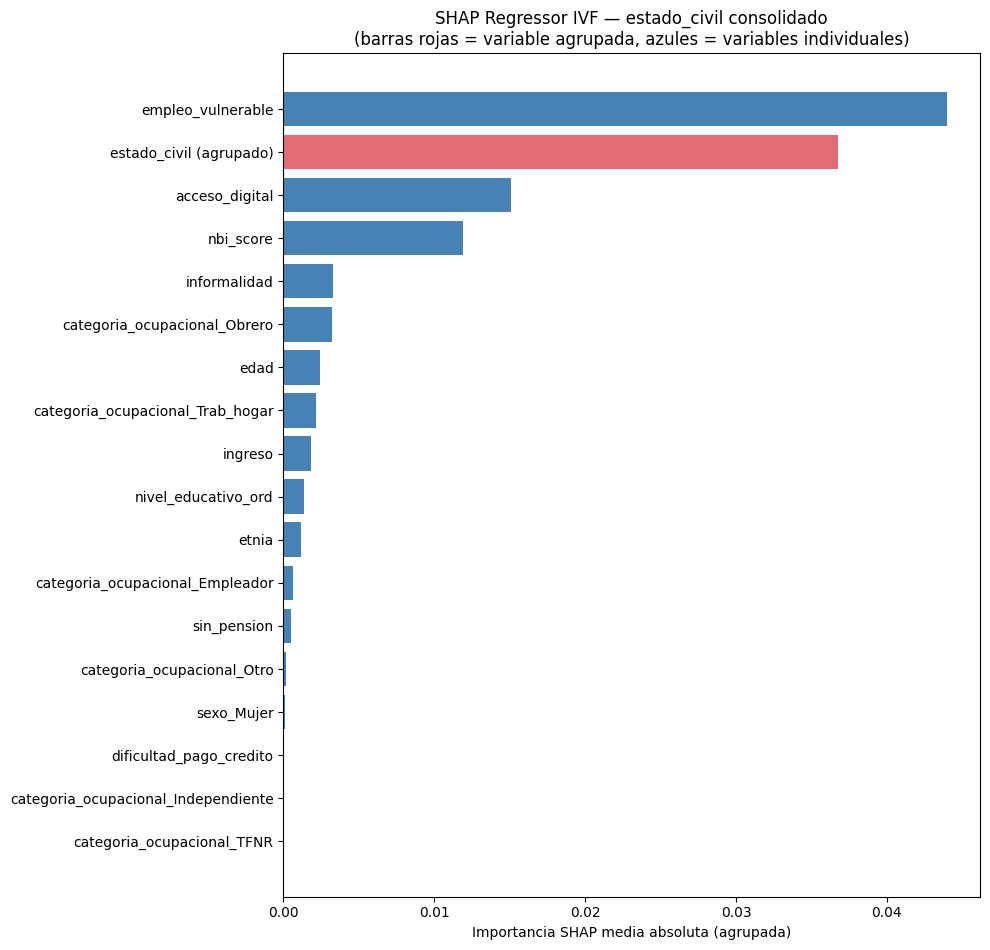

Dummies agrupadas: ['estado_civil_Conviviente', 'estado_civil_Divorciado/a', 'estado_civil_Separado/a', 'estado_civil_Soltero/a', 'estado_civil_Viudo/a']
  → estado_civil (agrupado) : 0.0368
  → edad (separada)         : 0.0024


In [ ]:
# ============================================================
# BLOQUE 24 — XGBoost Regressor para explicar el IVF
# ============================================================
# Mientras los Bloques 21–22 explican la pertenencia al PERFIL,
# aquí se explica directamente el valor continuo del IVF.
#
# Esto permite:
#   - Identificar qué variables incrementan el IVF (vulnerabilidad)
#   - Producir gráficos SHAP con dirección (valor alto = más vulnerable)
#   - Comparar con la explicación del clasificador de perfiles

from sklearn.metrics import mean_squared_error, r2_score

# Usar modelo sin geografía como base (el IVF fue construido sin geo)
X_reg = X_sin.copy()   # mismas variables que modelo sin geo
y_reg = df_final["IVF"].values

# Alinear índices por si hubo resets
X_reg = X_reg.reset_index(drop=True)

X_tr_r, X_te_r, y_tr_r, y_te_r, w_tr_r, w_te_r = train_test_split(
    X_reg, y_reg, w_xgb, test_size=0.2, random_state=SEED
)

model_reg = xgb.XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    random_state=SEED, verbosity=0,
)
model_reg.fit(X_tr_r, y_tr_r, sample_weight=w_tr_r)

y_pred_r = model_reg.predict(X_te_r)
rmse     = np.sqrt(mean_squared_error(y_te_r, y_pred_r))
r2       = r2_score(y_te_r, y_pred_r)

print(f"XGBoost Regressor — IVF como variable dependiente:")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")

# SHAP Regressor
explainer_reg = shap.TreeExplainer(model_reg)
shap_vals_reg = explainer_reg.shap_values(X_te_r)

# Summary plot (beeswarm)
shap.summary_plot(shap_vals_reg, X_te_r, show=False, plot_size=(10, 6))
plt.title("SHAP — XGBoost Regressor sobre IVF")
plt.tight_layout()
plt.savefig("shap_ivf_regressor.png", dpi=150, bbox_inches="tight"); plt.show()

# Bar plot de importancia
shap.summary_plot(shap_vals_reg, X_te_r, plot_type="bar", show=False, plot_size=(10, 5))
plt.title("Importancia SHAP — XGBoost Regressor sobre IVF")
plt.tight_layout()
plt.savefig("shap_ivf_bar.png", dpi=150, bbox_inches="tight"); plt.show()

# ── Agrupación SHAP: dummies de estado_civil → una sola barra ───────────────
# Las dummies estado_civil_Soltero/a, estado_civil_Conviviente, etc. aparecen
# separadas porque get_dummies las expande. Se consolidan en una sola
# importancia para ver el peso real de la variable frente a edad.

cols_ec   = [c for c in X_te_r.columns if c.startswith("estado_civil_")]
idx_ec    = [list(X_te_r.columns).index(c) for c in cols_ec]
otras     = [c for c in X_te_r.columns if not c.startswith("estado_civil_")]
idx_otras = [list(X_te_r.columns).index(c) for c in otras]

# shap_vals_reg es 2D (n, p) para el regressor
imp_ec    = np.abs(shap_vals_reg[:, idx_ec]).mean(axis=0).sum()
imp_otras = np.abs(shap_vals_reg[:, idx_otras]).mean(axis=0)

imp_agrup = pd.Series(imp_otras, index=otras)
imp_agrup["estado_civil (agrupado)"] = imp_ec
imp_agrup = imp_agrup.sort_values(ascending=False)

top_n = min(20, len(imp_agrup))
colores = ["#e06c75" if v == "estado_civil (agrupado)" else "steelblue"
           for v in imp_agrup.head(top_n).index]

fig, ax = plt.subplots(figsize=(10, top_n * 0.45 + 1.5))
ax.barh(range(top_n), imp_agrup.head(top_n).values[::-1], color=colores[::-1])
ax.set_yticks(range(top_n))
ax.set_yticklabels(imp_agrup.head(top_n).index[::-1])
ax.set_xlabel("Importancia SHAP media absoluta (agrupada)")
ax.set_title("SHAP Regressor IVF — estado_civil consolidado\n"
             "(barras rojas = variable agrupada, azules = variables individuales)")
plt.tight_layout()
plt.savefig("shap_ivf_agrupado.png", dpi=150, bbox_inches="tight"); plt.show()

print(f"Dummies agrupadas: {cols_ec}")
print(f"  → estado_civil (agrupado) : {imp_ec:.4f}")
print(f"  → edad (separada)         : {imp_agrup.get('edad', 0):.4f}")

SHAP por perfil — XGBoost Regressor IVF (K=5)

Observaciones en test set: 5991
  Perfil 1: 2596 obs. en test
  Perfil 2: 1055 obs. en test
  Perfil 3: 449 obs. en test
  Perfil 4: 855 obs. en test
  Perfil 5: 1036 obs. en test


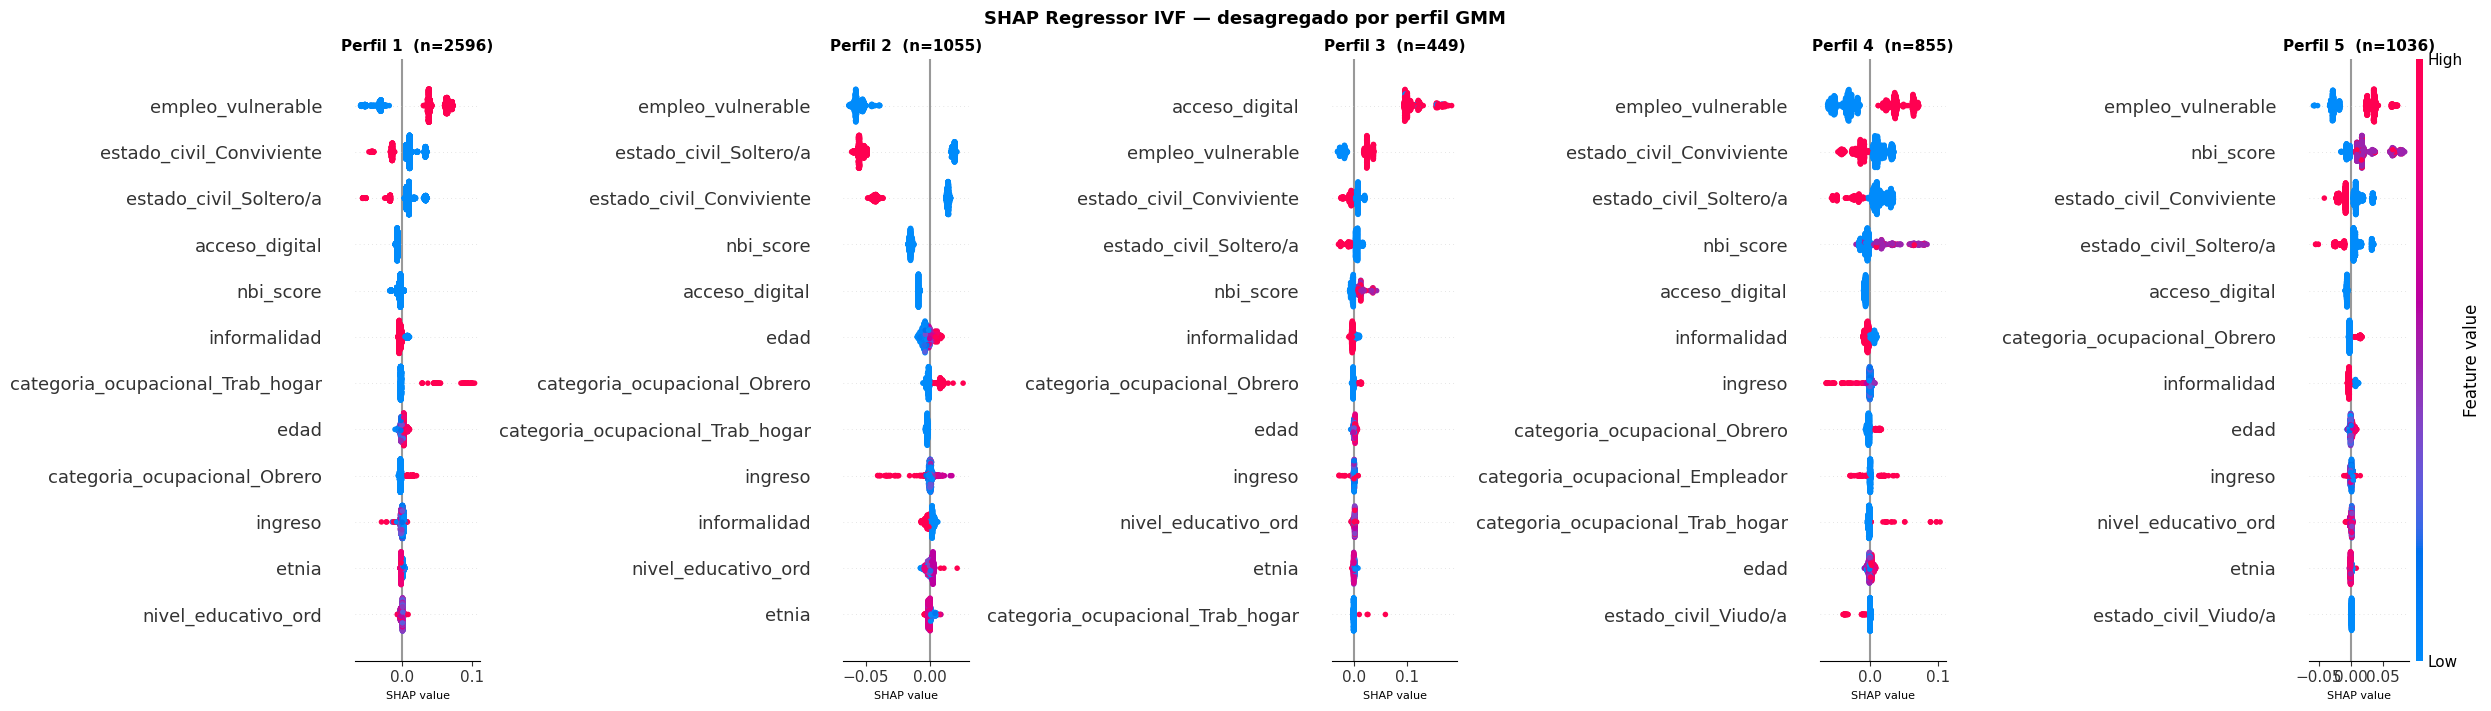

✔ Guardado: shap_por_perfil_beeswarm.png


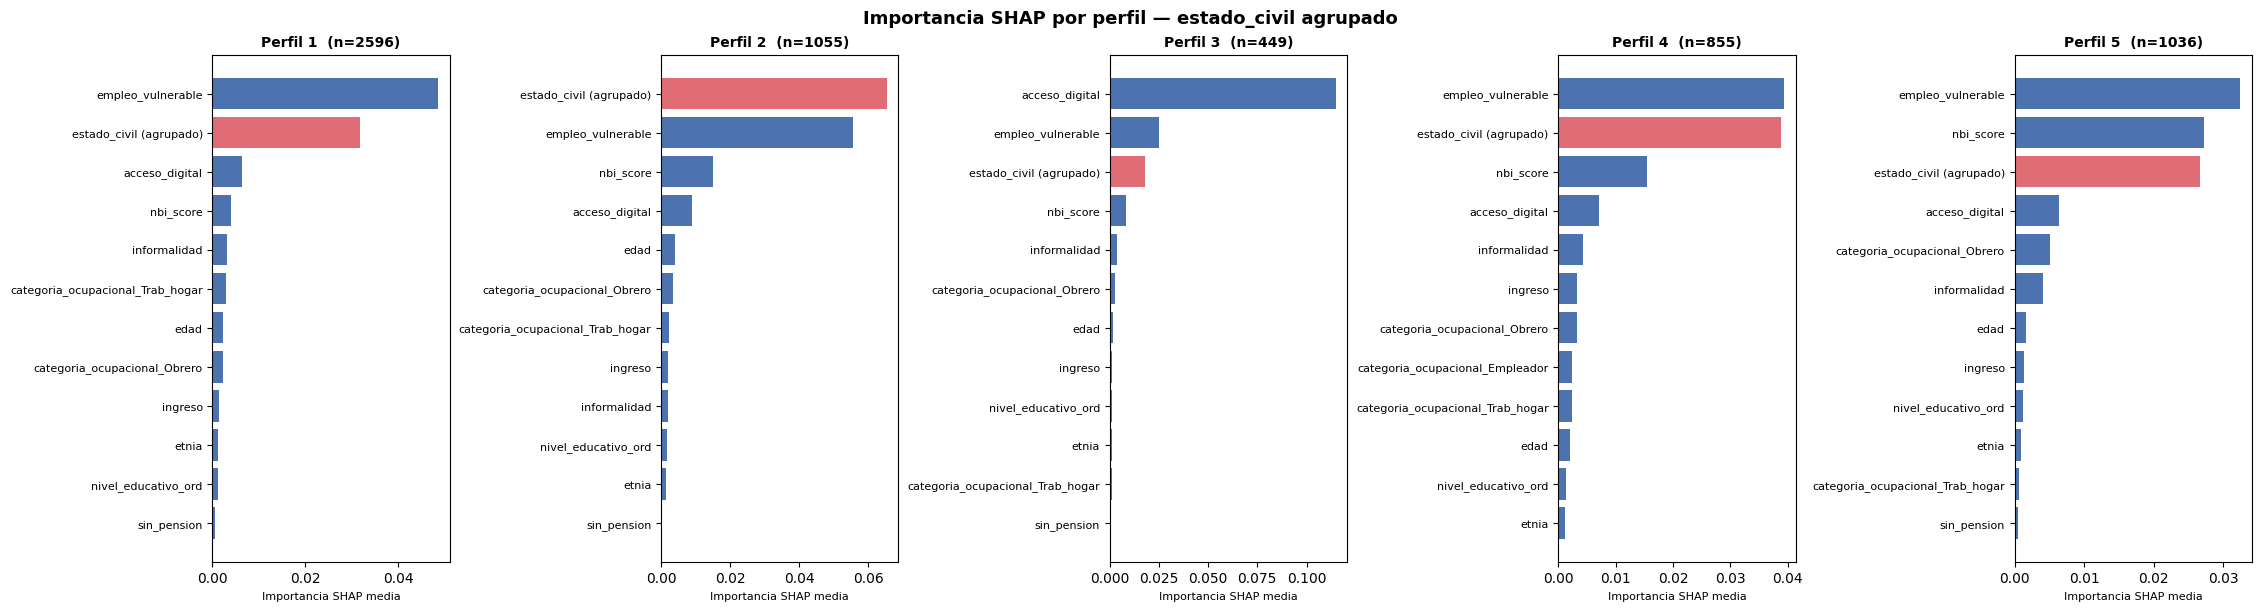

✔ Guardado: shap_por_perfil_barras.png


In [ ]:
# ============================================================
# BLOQUE 24-BIS — SHAP del Regressor IVF desagregado por perfil
# ============================================================
# Para cada perfil GMM, se filtran las observaciones del test set
# que pertenecen a ese perfil y se grafica su distribución SHAP.
# Esto responde: "¿qué variables explican la vulnerabilidad
# DENTRO de cada perfil?" — puede diferir del global.
#
# Requiere: shap_vals_reg, X_te_r, labels, best_k  (del Bloque 24 y 16)

# Alinear etiquetas de perfil al test set
# X_te_r tiene índices del split — recuperamos los labels correspondientes
idx_te = X_te_r.index  # índices originales del test set

# df_final tiene los labels asignados en el Bloque 16
labels_full = pd.Series(labels, index=df_final.reset_index(drop=True).index)
labels_te   = labels_full.loc[idx_te].values  # perfil de cada obs en test

# Agrupación estado_civil para los gráficos de barras por perfil
cols_ec   = [c for c in X_te_r.columns if c.startswith("estado_civil_")]
idx_ec    = [list(X_te_r.columns).index(c) for c in cols_ec]
otras     = [c for c in X_te_r.columns if not c.startswith("estado_civil_")]
idx_otras = [list(X_te_r.columns).index(c) for c in otras]

print(f"SHAP por perfil — XGBoost Regressor IVF (K={best_k})\n")
print(f"Observaciones en test set: {len(X_te_r)}")
for k in range(best_k):
    print(f"  Perfil {k+1}: {(labels_te == k).sum()} obs. en test")

# ── Figura 1: Beeswarm por perfil (subplots) ────────────────────────────────
fig, axes = plt.subplots(1, best_k, figsize=(5 * best_k, 7), constrained_layout=True)

for k in range(best_k):
    mask_k = labels_te == k
    n_k    = mask_k.sum()

    if n_k < 10:
        axes[k].set_title(f"Perfil {k+1}\n(n={n_k}, insuficiente)")
        axes[k].axis("off")
        continue

    shap_k = shap_vals_reg[mask_k]   # (n_k, p)
    X_k    = X_te_r.iloc[mask_k]     # (n_k, p)

    plt.sca(axes[k])
    shap.summary_plot(
        shap_k, X_k,
        show=False,
        plot_size=None,       # usa el axes actual
        max_display=12,
        color_bar=(k == best_k - 1),   # barra de color solo en el último
    )
    axes[k].set_title(f"Perfil {k+1}  (n={n_k})", fontsize=11, fontweight="bold")
    axes[k].set_xlabel("SHAP value", fontsize=8)

fig.suptitle("SHAP Regressor IVF — desagregado por perfil GMM",
             fontsize=13, fontweight="bold", y=1.02)
plt.savefig("shap_por_perfil_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Guardado: shap_por_perfil_beeswarm.png")

# ── Figura 2: Barras de importancia por perfil (agrupando estado_civil) ─────
fig2, axes2 = plt.subplots(1, best_k, figsize=(4.5 * best_k, 6), constrained_layout=True)

for k in range(best_k):
    mask_k = labels_te == k
    n_k    = mask_k.sum()

    if n_k < 10:
        axes2[k].set_title(f"Perfil {k+1}\n(n insuficiente)")
        axes2[k].axis("off")
        continue

    shap_k = shap_vals_reg[mask_k]

    # Importancias individuales
    imp_ec    = np.abs(shap_k[:, idx_ec]).mean(axis=0).sum()
    imp_otras = np.abs(shap_k[:, idx_otras]).mean(axis=0)

    imp_s = pd.Series(imp_otras, index=otras)
    imp_s["estado_civil (agrupado)"] = imp_ec
    imp_s = imp_s.sort_values(ascending=False).head(12)

    colores = ["#e06c75" if v == "estado_civil (agrupado)" else "#4c72b0"
               for v in imp_s.index]

    axes2[k].barh(range(len(imp_s)), imp_s.values[::-1], color=colores[::-1])
    axes2[k].set_yticks(range(len(imp_s)))
    axes2[k].set_yticklabels(imp_s.index[::-1], fontsize=8)
    axes2[k].set_xlabel("Importancia SHAP media", fontsize=8)
    axes2[k].set_title(f"Perfil {k+1}  (n={n_k})", fontsize=10, fontweight="bold")

fig2.suptitle("Importancia SHAP por perfil — estado_civil agrupado",
              fontsize=13, fontweight="bold")
plt.savefig("shap_por_perfil_barras.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Guardado: shap_por_perfil_barras.png")

IVF medio ponderado por área:
  Urbano  : IVF = 0.4557  Vi = 0.4374  (~7,236,591 personas)
  Rural   : IVF = 0.4920  Vi = 0.5583  (~2,007,004 personas)

Distribución de perfiles (% ponderado) por área:
          Urbano  Rural
Perfil 1   0.402  0.428
Perfil 2   0.257  0.119
Perfil 3   0.044  0.102
Perfil 4   0.158  0.111
Perfil 5   0.140  0.241


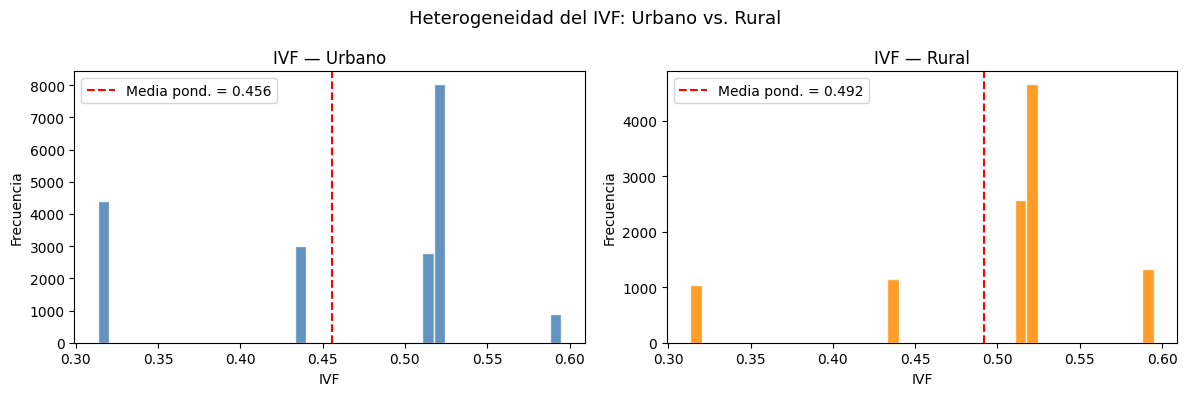


SHAP por área (modelo XGBoost sin geografía):


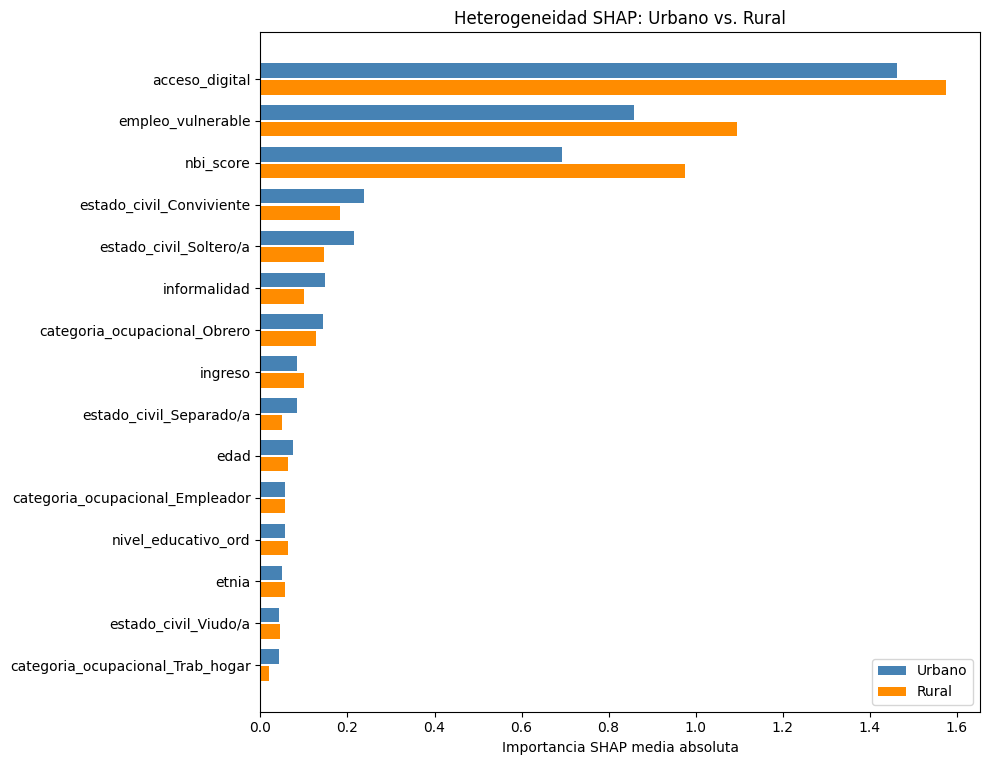

In [ ]:
# ============================================================
# BLOQUE 25 — Heterogeneidad urbano / rural
# ============================================================
# Compara la distribución del IVF y la composición de perfiles
# entre población urbana y rural.
#
# También compara importancias SHAP por área usando el modelo global
# XGBoost sin geografía; no reestima modelos separados por área.
# Esto permite evaluar si los predictores actúan de forma distinta
# en población urbana y rural.

if "area" not in df_final.columns:
    print("⚠ Variable 'area' no encontrada. Verificar Bloque 7.")
else:
    areas = ["Urbano", "Rural"]

    # --- IVF medio ponderado por área ---
    print("IVF medio ponderado por área:")
    for area in areas:
        mask    = df_final["area"] == area
        if mask.sum() == 0:
            continue
        ivf_a   = np.average(df_final.loc[mask, "IVF"], weights=factor_raw[mask])
        vi_a    = np.average(df_final.loc[mask, "Vi"],  weights=factor_raw[mask])
        n_pob   = factor_raw[mask].sum()
        print(f"  {area:<8}: IVF = {ivf_a:.4f}  Vi = {vi_a:.4f}  (~{n_pob:,.0f} personas)")

    # --- Distribución de perfiles por área ---
    print("\nDistribución de perfiles (% ponderado) por área:")
    tabla_area = {}
    for area in areas:
        mask = df_final["area"] == area
        if mask.sum() == 0:
            continue
        w_a  = factor_raw[mask]
        lbl  = labels[mask]
        dist = {f"Perfil {k+1}": (lbl == k).astype(float) @ w_a / w_a.sum()
                for k in range(best_k)}
        tabla_area[area] = dist
    df_area = pd.DataFrame(tabla_area).round(3)
    print(df_area.to_string())

    # --- Histogramas IVF por área ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
    for ax, area in zip(axes, areas):
        mask = df_final["area"] == area
        if mask.sum() == 0:
            continue
        ivf_a = df_final.loc[mask, "IVF"]
        ax.hist(ivf_a, bins=40, color="steelblue" if area == "Urbano" else "darkorange",
                edgecolor="white", alpha=0.85)
        ivf_pond = np.average(ivf_a, weights=factor_raw[mask])
        ax.axvline(ivf_pond, color="red", linestyle="--",
                   label=f"Media pond. = {ivf_pond:.3f}")
        ax.set_title(f"IVF — {area}"); ax.set_xlabel("IVF"); ax.set_ylabel("Frecuencia")
        ax.legend()
    plt.suptitle("Heterogeneidad del IVF: Urbano vs. Rural", fontsize=13)
    plt.tight_layout()
    plt.savefig("heterogeneidad_urbano_rural.png", dpi=150); plt.show()

    # --- SHAP por área (modelo clasificador sin geo) ---
    print("\nSHAP por área (modelo XGBoost sin geografía):")
    shap_area = {}
    for area in areas:
        mask = (df_final["area"] == area).values
        if mask.sum() < 50:
            print(f"  ⚠ {area}: muy pocos casos ({mask.sum()}), se omite.")
            continue
        X_area = X_sin.reset_index(drop=True).loc[mask]
        sv     = explainer_sin.shap_values(X_area)
        if isinstance(sv, list):
            imp = pd.Series(
                np.abs(np.stack(sv)).mean(axis=(0, 1)),
                index=X_area.columns
            )
        else:
            # Fix: average over samples (axis 0) and classes (axis 2) to get 1D array
            imp = pd.Series(np.abs(sv).mean(axis=(0, 2)), index=X_area.columns)
        shap_area[area] = imp

    if len(shap_area) == 2:
        df_shap_area = pd.concat(shap_area, axis=1).sort_values("Urbano", ascending=False)
        top_n = min(15, len(df_shap_area))
        df_shap_plot = df_shap_area.head(top_n)
        x  = np.arange(len(df_shap_plot))
        fig, ax = plt.subplots(figsize=(10, top_n * 0.45 + 1))
        ax.barh(x - 0.2, df_shap_plot["Urbano"], 0.35, label="Urbano",  color="steelblue")
        ax.barh(x + 0.2, df_shap_plot["Rural"],  0.35, label="Rural",   color="darkorange")
        ax.set_yticks(x); ax.set_yticklabels(df_shap_plot.index)
        ax.set_xlabel("Importancia SHAP media absoluta")
        ax.set_title("Heterogeneidad SHAP: Urbano vs. Rural")
        ax.legend(); ax.invert_yaxis()
        plt.tight_layout()
        plt.savefig("shap_heterogeneidad_area.png", dpi=150); plt.show()

Bootstrap simple de estabilidad — B = 200 iteraciones con K = 5 perfiles...
  10/200 completadas...
  20/200 completadas...
  30/200 completadas...
  40/200 completadas...
  50/200 completadas...
  60/200 completadas...
  70/200 completadas...
  80/200 completadas...
  90/200 completadas...
  100/200 completadas...
  110/200 completadas...
  120/200 completadas...
  130/200 completadas...
  140/200 completadas...
  150/200 completadas...
  160/200 completadas...
  170/200 completadas...
  180/200 completadas...
  190/200 completadas...
  200/200 completadas...

Robustez del IVF medio (B=200):
  Modelo final    : 0.4635
  Boot media      : 0.4636
  Boot IC 95%     : [0.4635, 0.4637]
  Boot CV         : 0.0001

Robustez de Rk por perfil (B=200):
  Perfil 1: Rk_final=0.5188  boot_media=0.5040  IC95=[0.4748, 0.5542]
  Perfil 2: Rk_final=0.3133  boot_media=0.4013  IC95=[0.2416, 0.4437]
  Perfil 3: Rk_final=0.5951  boot_media=0.5895  IC95=[0.5402, 0.6051]
  Perfil 4: Rk_final=0.4357  boot_me

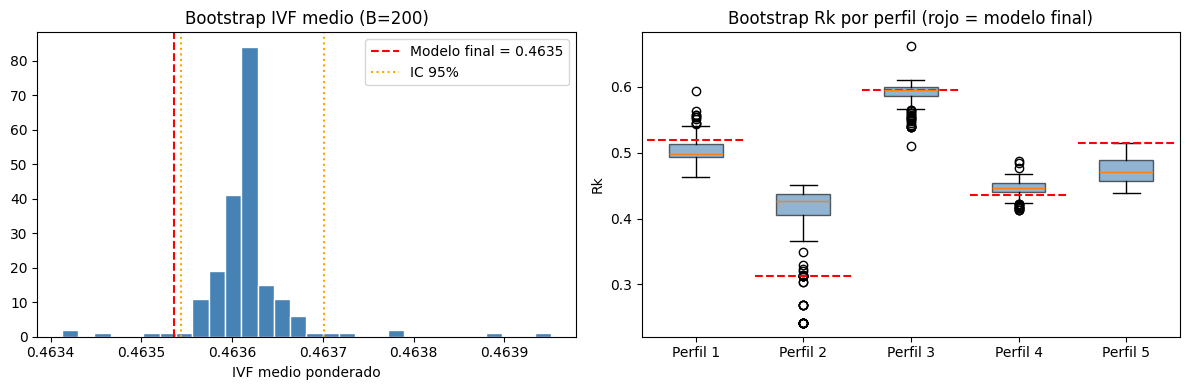

In [ ]:
# ============================================================
# BLOQUE 26 — Bootstrap simple de robustez con resúmenes ponderados
# ============================================================
# Se repite un remuestreo simple con reemplazo B veces y se re-estima
# el GMM en cada iteración. FAC500A no define la probabilidad de selección
# del remuestreo; se usa después para calcular:
#   - Rk (vulnerabilidad media ponderada por perfil)
#   - IVF medio global ponderado
#   - Distribución ponderada de perfiles (tamaño relativo poblacional)
#
# B = 200 iteraciones en esta versión.
#
# Nota: la asignación de perfiles entre iteraciones puede permutar
# (label switching). Se resuelve alineando cada iteración con el
# modelo final por correlación de Rk.

B = 200
boot_ivf_medios  = []
boot_rk_matrix   = []   # B × K
boot_dist_perfiles = [] # B × K

print(f"Bootstrap simple de estabilidad — B = {B} iteraciones con K = {best_k} perfiles...")

rk_ref = np.array([rk[k] for k in range(best_k)])  # Rk del modelo final

rng = np.random.default_rng(SEED) # Initialize random number generator

for b in range(B):
    # Remuestreo simple (sin pesos) — bootstrap clásico de estabilidad
    idx_b = rng.choice(np.arange(len(X_gmm)), size=len(X_gmm), replace=True)
    X_wb  = X_gmm[idx_b]

    # GMM con misma K
    gmm_b  = GaussianMixture(
        n_components=best_k, covariance_type="full",
        random_state=b, n_init=5
    )
    gmm_b.fit(X_wb)
    labels_b  = gmm_b.predict(X_gmm)
    proba_b   = gmm_b.predict_proba(X_gmm)

    # Rk de esta iteración
    rk_b = np.zeros(best_k)
    for k in range(best_k):
        mask_k  = labels_b == k
        if mask_k.sum() == 0:
            rk_b[k] = np.nan
        else:
            rk_b[k] = np.average(
                df_final.loc[mask_k, "Vi"].values,
                weights=factor_raw[mask_k]
            )

    # Alinear perfiles por correlación con Rk de referencia
    # (resolver label switching)
    from itertools import permutations
    best_perm  = list(range(best_k))
    best_corr  = -np.inf
    for perm in permutations(range(best_k)):
        corr = np.corrcoef(rk_ref, rk_b[list(perm)])[0, 1]
        if corr > best_corr:
            best_corr = corr
            best_perm = list(perm)
    rk_b_alineado = rk_b[best_perm]

    # IVF con esta iteración
    ivf_b = np.zeros(len(df_final))
    for k_new, k_orig in enumerate(best_perm):
        ivf_b += proba_b[:, k_orig] * rk_b[k_orig]
    ivf_medio_b = np.average(ivf_b, weights=factor_raw)

    # Distribución de perfiles (ponderada)
    dist_b = np.array([
        factor_raw[labels_b == best_perm[k]].sum() / factor_raw.sum()
        for k in range(best_k)
    ])

    boot_ivf_medios.append(ivf_medio_b)
    boot_rk_matrix.append(rk_b_alineado)
    boot_dist_perfiles.append(dist_b)

    if (b + 1) % 10 == 0:
        print(f"  {b+1}/{B} completadas...")

boot_ivf_medios    = np.array(boot_ivf_medios)
boot_rk_matrix     = np.array(boot_rk_matrix)      # B × K
boot_dist_perfiles = np.array(boot_dist_perfiles)   # B × K

# --- Resultados de robustez ---
ivf_ref = np.average(df_final["IVF"], weights=factor_raw)

print(f"\nRobustez del IVF medio (B={B}):")
print(f"  Modelo final    : {ivf_ref:.4f}")
print(f"  Boot media      : {boot_ivf_medios.mean():.4f}")
print(f"  Boot IC 95%     : [{np.percentile(boot_ivf_medios, 2.5):.4f}, "
      f"{np.percentile(boot_ivf_medios, 97.5):.4f}]")
print(f"  Boot CV         : {boot_ivf_medios.std() / boot_ivf_medios.mean():.4f}")

print(f"\nRobustez de Rk por perfil (B={B}):")
for k in range(best_k):
    rk_boot_k = boot_rk_matrix[:, k]
    print(f"  Perfil {k+1}: Rk_final={rk[k]:.4f}  "
          f"boot_media={rk_boot_k.mean():.4f}  "
          f"IC95=[{np.percentile(rk_boot_k,2.5):.4f}, {np.percentile(rk_boot_k,97.5):.4f}]")

# Gráfico: distribución bootstrap del IVF medio
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(boot_ivf_medios, bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(ivf_ref, color="red", linestyle="--", label=f"Modelo final = {ivf_ref:.4f}")
axes[0].axvline(np.percentile(boot_ivf_medios, 2.5),  color="orange", linestyle=":")
axes[0].axvline(np.percentile(boot_ivf_medios, 97.5), color="orange", linestyle=":",
                label="IC 95%")
axes[0].set_xlabel("IVF medio ponderado")
axes[0].set_title(f"Bootstrap IVF medio (B={B})")
axes[0].legend()

# Boxplot de Rk por perfil
axes[1].boxplot(
    [boot_rk_matrix[:, k] for k in range(best_k)],
    labels=[f"Perfil {k+1}" for k in range(best_k)],
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6)
)
for k in range(best_k):
    axes[1].axhline(rk[k], xmin=(k)/best_k + 0.01, xmax=(k+1)/best_k - 0.01,
                   color="red", linestyle="--")
axes[1].set_ylabel("Rk")
axes[1].set_title("Bootstrap Rk por perfil (rojo = modelo final)")

plt.tight_layout()
plt.savefig("bootstrap_robustez.png", dpi=150); plt.show()

In [ ]:
# ============================================================
# BLOQUE 27 — Exportación de resultados
# ============================================================

# 1. Base individual con IVF, perfiles y todas las variables
df_export = df_final.drop(columns=["P507_raw", "P511A_raw", "factor_raw"],
                          errors="ignore")
df_export.to_csv("resultados_ivf.csv", index=False)

# 2. Criterios de selección de K
crit_df.to_csv("bic_icl_comparacion.csv", index=False)

# 3. Caracterización socioeconómica de perfiles (ya exportada en Bloque 19)
# stats_perfil.to_csv("estadisticas_perfiles.csv")   # redundante, ya exportado

# 4. Robustez bootstrap
boot_df = pd.DataFrame(
    boot_rk_matrix,
    columns=[f"Rk_perfil_{k+1}" for k in range(best_k)]
)
boot_df["IVF_medio"] = boot_ivf_medios
boot_df.to_csv("bootstrap_robustez.csv", index=False)

# 5. Importancias SHAP comparativas
df_comp.to_csv("shap_comparacion_geo.csv")

# 6. Resumen de robustez del IVF
resumen_boot = pd.DataFrame({
    "metrica"   : ["IVF_medio_modelo_final", "IVF_medio_boot", "IC95_inf", "IC95_sup", "CV_boot"],
    "valor"     : [
        ivf_ref,
        boot_ivf_medios.mean(),
        np.percentile(boot_ivf_medios, 2.5),
        np.percentile(boot_ivf_medios, 97.5),
        boot_ivf_medios.std() / boot_ivf_medios.mean(),
    ]
})
resumen_boot.to_csv("robustez_ivf_resumen.csv", index=False)

# ---- Listado final ----
archivos = [
    # CSV
    "resultados_ivf.csv",
    "bic_icl_comparacion.csv",
    "estadisticas_perfiles.csv",
    "bootstrap_robustez.csv",
    "shap_comparacion_geo.csv",
    "robustez_ivf_resumen.csv",
    # Gráficos
    "missings.png",
    "distribucion_vi.png",
    "mca_inercia.png",
    "seleccion_k_gmm.png",
    "distribucion_ivf.png",
    "heatmap_perfiles_socioeconomico.png",
    "geo_area_perfiles.png",
    "geo_dominio_macro_perfiles.png",
    "geo_tamano_poblacional_perfiles.png",
    "confusion_sin_geo.png",
    "shap_sin_geo.png",
    "confusion_con_geo.png",
    "shap_con_geo.png",
    "shap_comparacion_geo.png",
    "shap_ivf_regressor.png",
    "shap_ivf_bar.png",
    "heterogeneidad_urbano_rural.png",
    "shap_heterogeneidad_area.png",
    "bootstrap_robustez.png",
]

print("Archivos exportados:")
for f in archivos:
    existe = "✔" if os.path.exists(f) else "⚠ no encontrado"
    print(f"  {existe}  {f}")

print("\n✔ Pipeline completo — IVF construido, caracterizado y validado.")

Archivos exportados:
  ✔  resultados_ivf.csv
  ✔  bic_icl_comparacion.csv
  ✔  estadisticas_perfiles.csv
  ✔  bootstrap_robustez.csv
  ✔  shap_comparacion_geo.csv
  ✔  robustez_ivf_resumen.csv
  ✔  missings.png
  ✔  distribucion_vi.png
  ✔  mca_inercia.png
  ✔  seleccion_k_gmm.png
  ✔  distribucion_ivf.png
  ✔  heatmap_perfiles_socioeconomico.png
  ✔  geo_area_perfiles.png
  ✔  geo_dominio_macro_perfiles.png
  ✔  geo_tamano_poblacional_perfiles.png
  ✔  confusion_sin_geo.png
  ✔  shap_sin_geo.png
  ✔  confusion_con_geo.png
  ✔  shap_con_geo.png
  ✔  shap_comparacion_geo.png
  ✔  shap_ivf_regressor.png
  ✔  shap_ivf_bar.png
  ✔  heterogeneidad_urbano_rural.png
  ✔  shap_heterogeneidad_area.png
  ✔  bootstrap_robustez.png

✔ Pipeline completo — IVF construido, caracterizado y validado.
